# Training Mask R-CNN (v1)

## Overview

This notebook implements the main **Mask R-CNN v1 training pipeline** for the project. It applies the findings from the preceding EDA and experiment notebooks, where class ambiguity and the large proportion of small objects were identified as major limitations of detection quality. The objective here is to convert those findings into a reproducible training workflow and evaluate whether the resulting changes improve bounding-box detection and instance segmentation.

The workflow includes:

- construction of instance masks and detection targets from TACO annotations;
- a deterministic train-validation split with weighted sampling for class imbalance;
- geometric and photometric training augmentation;
- a reduced taxonomy that merges overlapping plastic classes and removes ambiguous catch-all annotations;
- staged optimization, beginning with the detection heads and continuing with full-model fine-tuning using separate learning rates;
- cosine learning-rate scheduling, gradient clipping, mixed-precision training, early stopping, and checkpoint recovery;
- a small-object model variant with lower-scale anchors, multi-scale input sizes, and the `map_17` taxonomy.

The primary model-selection metric is **bounding-box mAP@0.5**. Additional bounding-box, mask, recall, overlap, and diagnostic metrics are collected to distinguish localization failures from classification errors. Training history is written to CSV and TensorBoard, while best and latest checkpoints make long runs resumable across sessions.

> Some training cells resume from existing checkpoints. Their paths and starting epochs must match the checkpoint being loaded before the notebook is executed in a new environment.

## Note

This notebook was run in Thunder Compute environment

## Install Packages

In [ ]:
!pip install torchmetrics pycocotools gdown tqdm tensorboard albumentations

In [ ]:
!curl https://rclone.org/install.sh | sudo bash

## Import Packages

In [1]:
import os
import pandas as pd
import json
from tqdm import tqdm

import ast
from PIL import Image, ImageDraw
import os
import torch
import math

import numpy as np
from torchvision.io import read_image
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F
from torch.utils.data import Dataset, Subset, DataLoader, random_split, WeightedRandomSampler
from torch import nn
import random
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torch.utils.tensorboard import SummaryWriter
from matplotlib import colors, pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

from torchvision.ops import box_iou

from torchmetrics.detection import (
    MeanAveragePrecision,
    IntersectionOverUnion,
    GeneralizedIntersectionOverUnion,
    DistanceIntersectionOverUnion,
    CompleteIntersectionOverUnion,
)
from torchmetrics.segmentation import DiceScore, GeneralizedDiceScore, MeanIoU

%matplotlib inline

## Set Environments Path

In [2]:
def is_google_colab() -> bool:
    """Check whether the notebook is running in Google Colab.
    
    Returns:
        bool: ``True`` in a Colab runtime; otherwise ``False``.
    """
    try:
        import google.colab
        return True
    except ImportError:
        return False


IN_COLAB = is_google_colab()

if IN_COLAB:
    ROOT_PATH = "/content"
    DATAFRAME_PATH = "/content/drive/MyDrive/taco_trash"
    DEFAULT_RUNS_PATH = "/content/drive/MyDrive/taco_trash"
else:
    ROOT_PATH = "/home/ubuntu"
    DATAFRAME_PATH = os.path.join(ROOT_PATH, "taco_trash")
    DEFAULT_RUNS_PATH = os.path.join(ROOT_PATH, "taco_trash")

TACO_CLASSIFICATION_PATH = os.path.join(ROOT_PATH, "taco")

In [3]:
if is_google_colab():
    from google.colab import drive
    drive.mount("/content/drive")
else:
    !curl https://rclone.org/install.sh | sudo bash

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4734  100  4734    0     0  10038      0 --:--:-- --:--:-- --:--:-- 10050

The latest version of rclone rclone v1.74.3 is already installed.



In [4]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [5]:
torch.cuda.current_device()
torch.cuda.get_device_name(0)
device = torch.device("cuda")
device

device(type='cuda')

## Download Data

In [ ]:
!gdown 1CUxA2TcZFhVJWvNH4qwlOSGDPlxodRPF
!unzip taco.zip -d $ROOT_PATH

In [8]:
!gdown 1lj6H8pIbHjgrgNRWHoc41Nr8bi0FZ7mt # annotations_processed.csv

Downloading...
From: https://drive.google.com/uc?id=1lj6H8pIbHjgrgNRWHoc41Nr8bi0FZ7mt
To: /content/annotations_processed.csv
100% 3.10M/3.10M [00:00<00:00, 290MB/s]


In [7]:
def parse_bbox(v):
    if isinstance(v, str):
        return ast.literal_eval(v)
    return v
    
if is_google_colab():
    df = pd.read_csv(os.path.join(ROOT_PATH, "annotations_processed.csv"))
else:
    ann_path = os.path.join(TACO_CLASSIFICATION_PATH, "annotations.json")
    with open(ann_path, "r") as f:
        data = json.load(f)

    print(data.keys())

    for key in data.keys():
        if isinstance(data[key], list):
            print(key, len(data[key]))

    df_images = pd.DataFrame(data["images"])
    df_annotations = pd.DataFrame(data["annotations"])
    df_categories = pd.DataFrame(data["categories"])
    df_scene_annotations = pd.DataFrame(data["scene_annotations"])
    df_scene_categories = pd.DataFrame(data["scene_categories"])

    df = df_annotations.merge(
        df_images,
        left_on="image_id",
        right_on="id",
        how="left",
        suffixes=("", "_img"),
    ).merge(
        df_categories,
        left_on="category_id",
        right_on="id",
        how="left",
        suffixes=("", "_cat"),
    ).rename(
        columns={
            "id_x": "annotation_id",
            "id_y": "category_id_full",
            "name": "category_name",
        }
    )
    df['file_path'] = df['file_name'].map(lambda x: os.path.join(TACO_CLASSIFICATION_PATH, x) )

dict_keys(['info', 'images', 'annotations', 'scene_annotations', 'licenses', 'categories', 'scene_categories'])
images 1500
annotations 4784
scene_annotations 4296
licenses 0
categories 60
scene_categories 7


## Setup common functions

In [8]:
def polygons_to_masks(segmentation, height, width):
    """Rasterize polygon segmentations into binary masks.
    
    Args:
        segmentation (list[list[float]]): Polygon coordinate lists for one instance.
        height (int): Output mask height in pixels.
        width (int): Output mask width in pixels.
    
    Returns:
        torch.Tensor: Stacked masks with shape ``[N, H, W]``.
    """
    masks = []

    for seg in segmentation:
        # Create empty mask
        mask = Image.new("L", (width, height), 0)
        draw = ImageDraw.Draw(mask)

        # Create corrdinates tuples
        polygon = [(seg[i], seg[i+1]) for i in range(0, len(seg), 2)]

        # Fill this mask in empty mask image
        draw.polygon(polygon, outline=1, fill=1)

        #  PIL => numpy => torch
        mask = torch.from_numpy(np.array(mask, dtype=np.uint8))

        masks.append(mask)

    # Combine
    if len(masks) > 0:
        masks = torch.stack(masks)  # [N, H, W]
    else:
        masks = torch.zeros((0, height, width), dtype=torch.uint8)

    return masks

def boxes_from_masks(masks):
    """Compute tight ``xyxy`` bounding boxes from binary masks.
    
    Args:
        masks (torch.Tensor): Binary instance masks with shape ``[N, H, W]``.
    
    Returns:
        torch.Tensor: Bounding boxes with shape ``[N, 4]``.
    """
    boxes = []

    for mask in masks:
        ys, xs = torch.where(mask > 0)

        if len(xs) == 0 or len(ys) == 0:
            boxes.append([0.0, 0.0, 0.0, 0.0])
            continue

        x1 = xs.min().item()
        y1 = ys.min().item()
        x2 = xs.max().item() + 1
        y2 = ys.max().item() + 1

        boxes.append([float(x1), float(y1), float(x2), float(y2)])

    return torch.tensor(boxes, dtype=torch.float32)

def masks_to_boxes(masks):
    """Convert binary instance masks to tight ``xyxy`` boxes.
    
    Args:
        masks (torch.Tensor): Binary instance masks with shape ``[N, H, W]``.
    
    Returns:
        torch.Tensor: Bounding boxes with shape ``[N, 4]``.
    """
    boxes = []

    for mask in masks:
        ys, xs = torch.where(mask > 0)

        if len(xs) == 0 or len(ys) == 0:
            boxes.append([0, 0, 0, 0])
            continue

        x1 = xs.min().item()
        y1 = ys.min().item()
        x2 = xs.max().item() + 1
        y2 = ys.max().item() + 1

        boxes.append([x1, y1, x2, y2])

    return torch.tensor(boxes, dtype=torch.float32)

from PIL import Image, ExifTags

def load_image_with_exif(file_path):
    """Load an RGB image and apply its EXIF orientation.
    
    Args:
        file_path (str): Path to the source image.
    
    Returns:
        torch.Tensor: Normalized image tensor with shape ``[C, H, W]``.
    """
    image = Image.open(file_path).convert("RGB")
    try:
        exif = image._getexif()
        if exif:
            for tag, value in exif.items():
                if ExifTags.TAGS.get(tag) == "Orientation":
                    if value == 3:
                        image = image.rotate(180, expand=True)
                    elif value == 6:
                        image = image.rotate(270, expand=True)
                    elif value == 8:
                        image = image.rotate(90, expand=True)
                    break
    except Exception:
        pass
    return torch.from_numpy(np.array(image)).permute(2, 0, 1).float() / 255.0

class TacoDatasetOriginalBoxes(Dataset):
    def __init__(
        self,
        df,
        label_map,
        label_col="category_id",
        transform=None,
        return_masks=True,
        use_original_boxes=True,
    ):
        """Initialize the image-grouped TACO detection dataset.
        
        Args:
            df (pd.DataFrame): Object-level annotation dataframe.
            label_map (dict): Mapping from dataframe labels to contiguous model class IDs.
            label_col (str): Dataframe column containing the target class label.
            transform (Any | None): Optional joint image-and-mask transformation pipeline.
            return_masks (bool): Whether targets include binary instance masks.
            use_original_boxes (bool): Whether to use annotated boxes instead of mask-derived boxes.
        """
        self.image_groups = list(df.groupby("image_id"))
        self.label_map = label_map
        self.label_col = label_col
        self.transform = transform
        self.return_masks = return_masks
        self.use_original_boxes = use_original_boxes

    def __getitem__(self, idx):
        """Load one image and construct its detection target.
        
        Args:
            idx (int): Image-group index to load.
        
        Returns:
            tuple[torch.Tensor, dict]: Normalized image tensor and its target dictionary.
        """
        image_id, group = self.image_groups[idx]
        file_path = group.iloc[0]["file_path"]

        img = load_image_with_exif(file_path)
        _, H, W = img.shape

        boxes = []
        labels = []
        masks = []

        for _, row in group.iterrows():
            label = self.label_map[row[self.label_col]]
            labels.append(label)

            bbox = ast.literal_eval(row["bbox"]) if isinstance(row["bbox"], str) else row["bbox"]
            x, y, w, h = bbox
            boxes.append([x, y, x + w, y + h])

            if self.return_masks or self.transform is not None:
                segmentation = ast.literal_eval(row["segmentation"]) if isinstance(row["segmentation"],
                str) else row["segmentation"]
                mask = polygons_to_masks(segmentation, H, W)
                mask = mask.sum(dim=0).clamp(max=1).to(torch.uint8)
                masks.append(mask)

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        boxes[:, [0, 2]] = boxes[:, [0, 2]].clamp(0, W)
        boxes[:, [1, 3]] = boxes[:, [1, 3]].clamp(0, H)

        if len(masks) > 0:
            masks = torch.stack(masks)
        else:
            masks = torch.zeros((len(labels), H, W), dtype=torch.uint8)

        if self.transform is not None:
            image_np = (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            masks_np = [m.numpy() for m in masks]

            transformed = self.transform(
                image=image_np,
                masks=masks_np,
            )

            image_np = transformed["image"]
            masks_np = transformed["masks"]

            img = torch.from_numpy(image_np).permute(2, 0, 1).float() / 255.0

            masks = torch.stack([
                torch.from_numpy(m.astype(np.uint8))
                for m in masks_np
            ])

            boxes = masks_to_boxes(masks)

        keep = (
            (boxes[:, 2] > boxes[:, 0])
            & (boxes[:, 3] > boxes[:, 1])
        )

        if self.return_masks or self.transform is not None:
            keep = keep & (masks.flatten(1).sum(dim=1) > 0)

        boxes = boxes[keep]
        labels = labels[keep]
        masks = masks[keep]

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id]),
            "area": (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]),
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64),
        }

        if self.return_masks:
            target["masks"] = masks

        return img, target

    def __len__(self):
        """Return the number of unique images in the dataset.
        
        Returns:
            int: Number of image groups.
        """
        return len(self.image_groups)

In [9]:
from collections import Counter

def collate_fn(batch):
    """Transpose detection samples into image and target sequences.
    
    Args:
        batch (list): Detection samples returned by the dataset.
    
    Returns:
        tuple: Tuple containing image and target tuples.
    """
    return tuple(zip(*batch))

def get_loaders(
    df,
    label_map,
    label_col="supercategory_reduced",
    train_transform=None,
    return_masks=True,
    use_original_boxes=True,
    train_batch_size=2,
    val_batch_size=4,
    pin_memory=False,
    num_workers=2
):
    """Build deterministically split loaders with weighted sampling.
    
    Args:
        df (pd.DataFrame): Object-level annotation dataframe.
        label_map (dict): Mapping from dataframe labels to contiguous model class IDs.
        label_col (str): Dataframe column containing the target class label.
        train_transform (Any | None): Optional transformation applied only to training samples.
        return_masks (bool): Whether targets include binary instance masks.
        use_original_boxes (bool): Whether to use annotated boxes instead of mask-derived boxes.
        train_batch_size (int): Number of training images per batch.
        val_batch_size (int): Number of validation images per batch.
        pin_memory (bool): Whether data loaders use pinned host memory.
        num_workers (int): Number of worker processes used by each data loader.
    
    Returns:
        tuple[DataLoader, DataLoader]: Training and validation data loaders.
    """
    base_dataset = TacoDatasetOriginalBoxes(
      df=df,
      label_map=label_map,
      label_col=label_col,
      transform=None,
      return_masks=return_masks,
      use_original_boxes=use_original_boxes
    )

    train_size = int(0.8 * len(base_dataset))
    val_size = len(base_dataset) - train_size

    train_indices, val_indices = torch.utils.data.random_split(
        range(len(base_dataset)),
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42),
    )

    train_dataset_full = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=train_transform,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes
    )

    val_dataset_full = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=None,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes
    )
    train_dataset = Subset(train_dataset_full, train_indices.indices)
    val_dataset = Subset(val_dataset_full, val_indices.indices)
    class_counts = Counter()

    for dataset_idx in train_dataset.indices:
        image_id, group = base_dataset.image_groups[dataset_idx]

        labels = [
            label_map[cat_id]
            for cat_id in group[label_col].tolist()
        ]

        class_counts.update(labels)

    class_weights = {
        cls: 1.0 / np.sqrt(count)
        for cls, count in class_counts.items()
    }
    sample_weights = []

    for dataset_idx in train_dataset.indices:
        image_id, group = base_dataset.image_groups[dataset_idx]

        labels = [
            label_map[cat_id]
            for cat_id in group[label_col].tolist()
        ]

        weight = max(class_weights[label] for label in labels)
        sample_weights.append(weight)

    sample_weights = torch.DoubleTensor(sample_weights)

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=train_batch_size,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=False,
        sampler=sampler,
        collate_fn=collate_fn
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=val_batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=False,
        collate_fn=collate_fn
    )
    return train_loader, val_loader


In [10]:
def get_model(num_classes, train_mode="heads"):
    """Create a Mask R-CNN v1 model with configurable trainable components.
    
    Args:
        num_classes (int): Total class count including the background class.
        train_mode (str): Trainable component set: ``predictors``, ``heads``, or ``all``.
    
    Returns:
        torch.nn.Module: Configured model moved to the active device.
    """
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(
        weights="DEFAULT",
        min_size=1024,
        max_size=1536,
    )

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        256,
        num_classes,
    )

    for p in model.parameters():
        p.requires_grad = False

    if train_mode == "predictors":
        for p in model.roi_heads.box_predictor.parameters():
            p.requires_grad = True
        for p in model.roi_heads.mask_predictor.parameters():
            p.requires_grad = True

    elif train_mode == "heads":
        for p in model.rpn.parameters():
            p.requires_grad = True
        for p in model.roi_heads.parameters():
            p.requires_grad = True

    elif train_mode == "all":
        for p in model.parameters():
            p.requires_grad = True

    model.to(device)
    return model

def set_train_mode(model, train_mode):
    """Freeze the model and enable parameters selected by a training mode.
    
    Args:
        model (torch.nn.Module): Torchvision detection model.
        train_mode (str): Trainable component set: ``predictors``, ``heads``, or ``all``.
    
    Raises:
        ValueError: If ``train_mode`` is unsupported.
    """
    for p in model.parameters():
        p.requires_grad = False

    if train_mode == "predictors":
        for p in model.roi_heads.box_predictor.parameters():
            p.requires_grad = True
        for p in model.roi_heads.mask_predictor.parameters():
            p.requires_grad = True

    elif train_mode == "heads":
        for p in model.rpn.parameters():
            p.requires_grad = True
        for p in model.roi_heads.parameters():
            p.requires_grad = True

    elif train_mode == "all":
        for p in model.parameters():
            p.requires_grad = True

    else:
        raise ValueError(f"Unknown train_mode: {train_mode}")

def get_model_v2(num_classes, train_mode="heads"):
      """Create a Mask R-CNN v2 model with configurable trainable components.
      
      Args:
          num_classes (int): Total class count including the background class.
          train_mode (str): Trainable component set: ``predictors``, ``heads``, or ``all``.
      
      Returns:
          torch.nn.Module: Configured model moved to the active device.
      
      Raises:
          ValueError: If ``train_mode`` is unsupported.
      """
      model = torchvision.models.detection.maskrcnn_resnet50_fpn_v2(
          weights="DEFAULT",
          min_size=1024,
          max_size=1536,
      )

      in_features = model.roi_heads.box_predictor.cls_score.in_features
      model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

      in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
      model.roi_heads.mask_predictor = MaskRCNNPredictor(
          in_features_mask,
          256,
          num_classes,
      )

      for p in model.parameters():
          p.requires_grad = False

      if train_mode == "predictors":
          for p in model.roi_heads.box_predictor.parameters():
              p.requires_grad = True
          for p in model.roi_heads.mask_predictor.parameters():
              p.requires_grad = True

      elif train_mode == "heads":
          for p in model.rpn.parameters():
              p.requires_grad = True
          for p in model.roi_heads.parameters():
              p.requires_grad = True

      elif train_mode == "all":
          for p in model.parameters():
              p.requires_grad = True

      else:
          raise ValueError(f"Unknown train_mode: {train_mode}")

      model.to(device)
      return model

In [11]:
def fit_one_epoch(model, train_dataloader, optimizer, device, epoch, scaler=None, max_grad_norm=5.0):
    """Optimize the model for one epoch and aggregate training losses.
    
    Args:
        model (torch.nn.Module): Torchvision detection model.
        train_dataloader (DataLoader): Data loader providing training images and targets.
        optimizer (torch.optim.Optimizer): Optimizer for trainable model parameters.
        device (torch.device | str): Device used for model computation.
        epoch (int): Zero-based epoch index.
        scaler (torch.amp.GradScaler | None): Optional mixed-precision gradient scaler.
        max_grad_norm (float): Maximum gradient norm used for clipping.
    
    Returns:
        dict[str, float]: Mean losses, gradient norm, and epoch index.
    
    Raises:
        ValueError: If no batch is processed successfully.
    """
    model.to(device)
    model.train()

    total_loss_sum = 0.0
    num_batches = 0

    loss_sums = {
        "loss_classifier": 0.0,
        "loss_box_reg": 0.0,
        "loss_mask": 0.0,
        "loss_objectness": 0.0,
        "loss_rpn_box_reg": 0.0,
    }

    loader = tqdm(
        train_dataloader,
        total=len(train_dataloader),
        position=0,
        leave=True,
        dynamic_ncols=True,
        desc=f"Epoch {epoch+1}. Train"
    )
    for batch_idx, (images, targets) in enumerate(loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=scaler is not None):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())


        if not torch.isfinite(losses):
          print(f"non-finite loss at batch {batch_idx}")
          break

        if losses.item() > 1e6:
            print(f"exploding loss at batch {batch_idx}")
            print("targets summary:")
            for i, t in enumerate(targets):
                print(
                    i,
                    t["boxes"].shape,
                    t["labels"].tolist(),
                    t["masks"].shape,
                )
            break

        if scaler is not None:
            scaler.scale(losses).backward()
            scaler.unscale_(optimizer)

            grad_norm = torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                max_norm=max_grad_norm,
            )

            scaler.step(optimizer)
            scaler.update()
        else:
            losses.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                max_norm=max_grad_norm,
            )

            optimizer.step()

        total_loss_sum += losses.item()
        num_batches += 1

        for key in loss_sums:
            loss_sums[key] += loss_dict[key].item()

    if num_batches == 0:
        raise ValueError(
            f"fit_one_epoch: no successful batches were processed in epoch {epoch}"
        )

    metrics = {
        "epoch": epoch,
        "total_loss": total_loss_sum / num_batches,
        "grad_norm": float(grad_norm.detach().cpu()) if isinstance(grad_norm, torch.Tensor) else
          float(grad_norm),
    }

    for key in loss_sums:
        metrics[key] = loss_sums[key] / num_batches

    return metrics

In [12]:
def _to_float(x):
    """Convert a finite scalar tensor or number to a Python float.
    
    Args:
        x (Any): Value to convert.
    
    Returns:
        float | None: Finite scalar value, or ``None`` when unsupported.
    """
    if isinstance(x, torch.Tensor):
        if x.numel() == 1:
            value = float(x.detach().cpu().item())
            if math.isnan(value) or math.isinf(value):
                return None
            return value
        return None

    if isinstance(x, (int, float)):
        value = float(x)
        if math.isnan(value) or math.isinf(value):
            return None
        return value

    return None

def _to_list(x):
    """Convert tensor or scalar metric values to a Python list.
    
    Args:
        x (Any): Value to convert.
    
    Returns:
        list: Converted values, or an empty list when unsupported.
    """
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu()
        if x.ndim == 0:
            return [x.item()]
        return x.tolist()

    if isinstance(x, (int, float)):
        return [float(x)]

    if isinstance(x, list):
        return x

    return []

def iou_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    # Lets compute metrics for some threshold
    # first convert mask values to probabilities, then
    # apply thresholding

    """Calculate binary mask intersection over union.
    
    Args:
        logits (torch.Tensor): Raw mask prediction logits.
        labels (torch.Tensor): Binary ground-truth mask values.
        threshold (float): Probability threshold used to binarize predictions.
    
    Returns:
        torch.Tensor: Scalar IoU value.
    """
    prob_mask = logits.sigmoid()
    pred_mask = (prob_mask > threshold).float()

    tp = torch.sum(pred_mask*labels)
    fp = torch.sum(pred_mask) - tp
    fn = torch.sum(labels) - tp

    eps = 1e-8 # to avoid 0/0
    iou = (tp + eps) / (tp + fp + fn + eps)

    return iou

def prepare_detection_batch(preds, targets, mask_threshold=0.5):
    """Convert detector outputs and targets into TorchMetrics inputs.
    
    Args:
        preds (list[dict[str, torch.Tensor]]): Per-image model predictions.
        targets (list[dict[str, torch.Tensor]]): Per-image ground-truth targets.
        mask_threshold (float): Probability threshold used to binarize predicted masks.
    
    Returns:
        tuple[list, list, list, list]: Bounding-box and segmentation predictions and targets.
    """
    bbox_preds = []
    bbox_targets = []

    segm_preds = []
    segm_targets = []

    for pred, target in zip(preds, targets):
        pred_boxes = pred["boxes"].detach().cpu()
        pred_scores = pred["scores"].detach().cpu()
        pred_labels = pred["labels"].detach().cpu().to(torch.int64)

        gt_boxes = target["boxes"].detach().cpu()
        gt_labels = target["labels"].detach().cpu().to(torch.int64)

        bbox_preds.append({
            "boxes": pred_boxes,
            "scores": pred_scores,
            "labels": pred_labels,
        })

        bbox_targets.append({
            "boxes": gt_boxes,
            "labels": gt_labels,
        })

        segm_pred = {
            "boxes": pred_boxes,
            "scores": pred_scores,
            "labels": pred_labels,
        }
        if "masks" in pred:
            # pred masks come as [N, 1, H, W] floats
            segm_pred["masks"] = (pred["masks"].detach().cpu().squeeze(1) >= mask_threshold)

        segm_target = {
            "boxes": gt_boxes,
            "labels": gt_labels,
        }
        if "masks" in target:
            # gt masks are [N, H, W]
            segm_target["masks"] = target["masks"].detach().cpu().bool()

        segm_preds.append(segm_pred)
        segm_targets.append(segm_target)

    return bbox_preds, bbox_targets, segm_preds, segm_targets

def match_instance_masks(pred, target, box_iou_threshold=0.5, mask_threshold=0.5):
    """Match same-class instances by box IoU and return their masks.
    
    Args:
        pred (dict[str, torch.Tensor]): Predictions for one image.
        target (dict[str, torch.Tensor]): Ground-truth target for one image.
        box_iou_threshold (float): Minimum box IoU required for an instance match.
        mask_threshold (float): Probability threshold used to binarize predicted masks.
    
    Returns:
        tuple[torch.Tensor | None, torch.Tensor | None]: Matched predicted and ground-truth masks, or ``None`` values.
    """
    if len(pred["boxes"]) == 0 or len(target["boxes"]) == 0:
        return None, None

    pred_boxes = pred["boxes"].detach().cpu()
    pred_labels = pred["labels"].detach().cpu()
    pred_masks = (pred["masks"].detach().cpu().squeeze(1) >= mask_threshold)  # [Np, H, W]

    gt_boxes = target["boxes"].detach().cpu()
    gt_labels = target["labels"].detach().cpu()
    gt_masks = target["masks"].detach().cpu().bool()  # [Ng, H, W]

    ious = box_iou(pred_boxes, gt_boxes)  # [Np, Ng]
    same_label = pred_labels[:, None] == gt_labels[None, :]
    ious = ious * same_label.float()

    matched_pred_masks = []
    matched_gt_masks = []

    used_pred = set()
    used_gt = set()

    while True:
        max_iou = ious.max().item()
        if max_iou < box_iou_threshold:
            break

        flat_idx = ious.argmax().item()
        num_gt = ious.shape[1]
        pred_idx = flat_idx // num_gt
        gt_idx = flat_idx % num_gt

        if pred_idx in used_pred or gt_idx in used_gt:
            ious[pred_idx, gt_idx] = -1
            continue

        matched_pred_masks.append(pred_masks[pred_idx].long())
        matched_gt_masks.append(gt_masks[gt_idx].long())

        used_pred.add(pred_idx)
        used_gt.add(gt_idx)

        ious[pred_idx, :] = -1
        ious[:, gt_idx] = -1

    if len(matched_pred_masks) == 0:
        return None, None

    return torch.stack(matched_pred_masks), torch.stack(matched_gt_masks)

In [13]:
def prepare_eval_metrics_for_tensorboard(eval_results, id_to_name=None):
    """Flatten nested evaluation metrics into TensorBoard scalars.
    
    Args:
        eval_results (dict): Nested metrics returned by an evaluation epoch.
        id_to_name (dict[int, str] | None): Optional mapping from model IDs to readable class names.
    
    Returns:
        dict[str, float]: Finite scalar metrics keyed by log name.
    """
    flat = {}

    # bbox mAP dict
    bbox_map = eval_results["bbox_map"]
    flat["eval/bbox_map"] = _to_float(bbox_map.get("map"))
    flat["eval/bbox_map_50"] = _to_float(bbox_map.get("map_50"))
    flat["eval/bbox_map_75"] = _to_float(bbox_map.get("map_75"))
    flat["eval/bbox_mar_100"] = _to_float(bbox_map.get("mar_100"))

    # segm mAP dict
    if "segm_map" in eval_results:
        segm_map = eval_results["segm_map"]
        flat["eval/segm_map"] = _to_float(segm_map.get("map"))
        flat["eval/segm_map_50"] = _to_float(segm_map.get("map_50"))
        flat["eval/segm_map_75"] = _to_float(segm_map.get("map_75"))
        flat["eval/segm_mar_100"] = _to_float(segm_map.get("mar_100"))

    # box overlap metrics
    if "bbox_iou" in eval_results:
        flat["eval/bbox_iou"] = _to_float(eval_results["bbox_iou"])
        flat["eval/bbox_giou"] = _to_float(eval_results["bbox_giou"])
        flat["eval/bbox_diou"] = _to_float(eval_results["bbox_diou"])
        flat["eval/bbox_ciou"] = _to_float(eval_results["bbox_ciou"])

    # mask metrics
    if "dice" in eval_results:
        flat["eval/dice"] = _to_float(eval_results["dice"])
        flat["eval/generalized_dice"] = _to_float(eval_results["generalized_dice"])
        flat["eval/mask_miou"] = _to_float(eval_results["mask_miou"])

    if "debug" in eval_results:
        for key, value in eval_results["debug"].items():
            flat[f"eval/{key}"] = _to_float(value)

    # Per-class bbox AP
    if "classes" in bbox_map and "map_per_class" in bbox_map:
        classes = _to_list(bbox_map["classes"])
        values = _to_list(bbox_map["map_per_class"])

        for cls, value in zip(classes, values):
            cls = int(cls)
            cls_name = id_to_name.get(cls, str(cls)) if id_to_name else str(cls)
            flat[f"eval_per_class/bbox_map/{cls_name}"] = _to_float(value)

    # Per-class bbox recall
    if "classes" in bbox_map and "mar_100_per_class" in bbox_map:
        classes = _to_list(bbox_map["classes"])
        values = _to_list(bbox_map["mar_100_per_class"])

        for cls, value in zip(classes, values):
            cls = int(cls)
            cls_name = id_to_name.get(cls, str(cls)) if id_to_name else str(cls)
            flat[f"eval_per_class/bbox_mar_100/{cls_name}"] = _to_float(value)

    # Per-class mask AP
    if "segm_map" in eval_results:
        segm_map = eval_results["segm_map"]
        if "classes" in segm_map and "map_per_class" in segm_map:
            classes = _to_list(segm_map["classes"])
            values = _to_list(segm_map["map_per_class"])

            for cls, value in zip(classes, values):
                cls = int(cls)
                cls_name = id_to_name.get(cls, str(cls)) if id_to_name else str(cls)
                flat[f"eval_per_class/segm_map/{cls_name}"] = _to_float(value)

    # remove unsupported / None values
    flat = {k: v for k, v in flat.items() if v is not None}
    return flat

def prepare_train_metrics_for_tensorboard(train_metrics):
    """Convert training losses into TensorBoard scalar names.
    
    Args:
        train_metrics (dict): Metrics collected during the current training epoch.
    
    Returns:
        dict[str, float]: Training metrics keyed by log name.
    """
    return {
        "train/total_loss": float(train_metrics["total_loss"]),
        "train/loss_classifier": float(train_metrics["loss_classifier"]),
        "train/loss_box_reg": float(train_metrics["loss_box_reg"]),
        "train/loss_mask": float(train_metrics["loss_mask"]),
        "train/loss_objectness": float(train_metrics["loss_objectness"]),
        "train/loss_rpn_box_reg": float(train_metrics["loss_rpn_box_reg"]),
    }

In [14]:
from torchvision.ops import box_iou

def detection_debug_stats(outputs, targets, score_threshold=0.05, iou_threshold=0.5):
    """Collect confidence, localization, and class-match diagnostics.
    
    Args:
        outputs (list[dict[str, torch.Tensor]]): Per-image detector outputs.
        targets (list[dict[str, torch.Tensor]]): Per-image ground-truth targets.
        score_threshold (float): Minimum confidence required to retain a prediction.
        iou_threshold (float): Minimum IoU required for geometric matching.
    
    Returns:
        dict: Aggregated detection diagnostic counters and score lists.
    """
    stats = {
        "gt_instances": 0,
        "pred_instances": 0,
        "matched_instances": 0,
        "class_correct_matches": 0,
        "images_with_no_predictions": 0,
        "images_with_no_matches": 0,
        "top1_scores": [],
        "matched_scores": [],
        "unmatched_scores": [],
    }

    for out, target in zip(outputs, targets):
        scores = out["scores"].detach().cpu()
        keep = scores >= score_threshold

        pred_boxes = out["boxes"].detach().cpu()[keep]
        pred_labels = out["labels"].detach().cpu()[keep]
        pred_scores = scores[keep]

        gt_boxes = target["boxes"].detach().cpu()
        gt_labels = target["labels"].detach().cpu()

        stats["gt_instances"] += len(gt_boxes)
        stats["pred_instances"] += len(pred_boxes)

        if len(scores) > 0:
            stats["top1_scores"].append(float(scores[0]))

        if len(pred_boxes) == 0:
            stats["images_with_no_predictions"] += 1
            stats["images_with_no_matches"] += 1
            continue

        if len(gt_boxes) == 0:
            stats["unmatched_scores"].extend(pred_scores.tolist())
            continue

        ious = box_iou(pred_boxes, gt_boxes)

        matched_pred = set()
        matched_gt = set()

        while ious.numel() > 0:
            max_iou = ious.max().item()
            if max_iou < iou_threshold:
                break

            flat_idx = ious.argmax().item()
            pred_idx = flat_idx // ious.shape[1]
            gt_idx = flat_idx % ious.shape[1]

            if pred_idx in matched_pred or gt_idx in matched_gt:
                ious[pred_idx, gt_idx] = -1
                continue

            matched_pred.add(pred_idx)
            matched_gt.add(gt_idx)

            stats["matched_instances"] += 1
            stats["matched_scores"].append(float(pred_scores[pred_idx]))

            if int(pred_labels[pred_idx]) == int(gt_labels[gt_idx]):
                stats["class_correct_matches"] += 1

            ious[pred_idx, :] = -1
            ious[:, gt_idx] = -1

        if len(matched_gt) == 0:
            stats["images_with_no_matches"] += 1

        for pred_idx, score in enumerate(pred_scores):
            if pred_idx not in matched_pred:
                stats["unmatched_scores"].append(float(score))

    return stats

In [15]:
@torch.no_grad()
def eval_one_epoch(
    model,
    val_dataloader,
    device,
    epoch,
    score_threshold=0.3,
    mask_threshold=0.3,
    detections_per_img=5,
    match_iou_threshold=0.5,
    fast=False
):
    """Evaluate bounding-box metrics and optionally full mask metrics.
    
    Args:
        model (torch.nn.Module): Torchvision detection model.
        val_dataloader (DataLoader): Data loader providing validation images and targets.
        device (torch.device | str): Device used for model computation.
        epoch (int): Zero-based epoch index.
        score_threshold (float): Minimum confidence required to retain a prediction.
        mask_threshold (float): Probability threshold used to binarize predicted masks.
        detections_per_img (int): Maximum number of predictions retained per image.
        match_iou_threshold (float): Minimum box IoU used for diagnostic instance matching.
        fast (bool): Whether to skip expensive mask and overlap metrics.
    
    Returns:
        dict: Evaluation metrics and detection diagnostics.
    """
    model.eval()
    running_debug = {
        "gt_instances": 0,
        "pred_instances": 0,
        "matched_instances": 0,
        "class_correct_matches": 0,
        "images_with_no_predictions": 0,
        "images_with_no_matches": 0,
        "top1_scores": [],
        "matched_scores": [],
        "unmatched_scores": [],
    }
    model.roi_heads.score_thresh = score_threshold
    model.roi_heads.detections_per_img = detections_per_img

    bbox_map = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
    if not fast:
        segm_map = MeanAveragePrecision(box_format="xyxy", iou_type="segm")

        bbox_iou_metric = IntersectionOverUnion()
        bbox_giou_metric = GeneralizedIntersectionOverUnion()
        bbox_diou_metric = DistanceIntersectionOverUnion()
        bbox_ciou_metric = CompleteIntersectionOverUnion()

        dice_metric = DiceScore(
            num_classes=2,
            average="micro",
            include_background=False,
            input_format="index",
        )
        gdice_metric = GeneralizedDiceScore(
            num_classes=2,
            include_background=False,
            input_format="index",
        )
        miou_metric = MeanIoU(
            num_classes=2,
            include_background=False,
            input_format="index",
        )

    matched_mask_count = 0

    loader = tqdm(
        val_dataloader,
        total=len(val_dataloader),
        position=0,
        leave=True,
        dynamic_ncols=True,
        desc=f"Epoch {epoch+1}. Eval"
)
    for batch_idx, (images, targets) in enumerate(loader):

        images = [img.to(device) for img in images]

        with torch.amp.autocast("cuda"):
            outputs = model(images)

        debug_stats = detection_debug_stats(
            outputs=outputs,
            targets=targets,
            score_threshold=0.05,
            iou_threshold=0.5,
        )

        for key in [
            "gt_instances",
            "pred_instances",
            "matched_instances",
            "class_correct_matches",
            "images_with_no_predictions",
            "images_with_no_matches",
        ]:
            running_debug[key] += debug_stats[key]

        for key in [
            "top1_scores",
            "matched_scores",
            "unmatched_scores",
        ]:
            running_debug[key].extend(debug_stats[key])

        bbox_preds, bbox_targets, segm_preds, segm_targets = prepare_detection_batch(
            outputs,
            targets,
            mask_threshold=mask_threshold,
        )

        bbox_map.update(bbox_preds, bbox_targets)
        # segm_map.update(segm_preds, segm_targets)
        if not fast:
            if any("masks" in p for p in segm_preds):
                segm_map.update(segm_preds, segm_targets)

            bbox_iou_metric.update(bbox_preds, bbox_targets)
            bbox_giou_metric.update(bbox_preds, bbox_targets)
            bbox_diou_metric.update(bbox_preds, bbox_targets)
            bbox_ciou_metric.update(bbox_preds, bbox_targets)

            for target, out in zip(targets, outputs):
                if "masks" not in out or "masks" not in target:
                    continue

                pred_masks, gt_masks = match_instance_masks(
                    out,
                    target,
                    box_iou_threshold=match_iou_threshold,
                    mask_threshold=mask_threshold,
                )

                if pred_masks is None:
                    continue

                dice_metric.update(pred_masks, gt_masks)
                gdice_metric.update(pred_masks, gt_masks)
                miou_metric.update(pred_masks, gt_masks)

                matched_mask_count += pred_masks.shape[0]

        del images, outputs

    if matched_mask_count > 0:
        dice = dice_metric.compute()
        generalized_dice = gdice_metric.compute()
        mask_miou = miou_metric.compute()
    else:
        dice = torch.tensor(float("nan"))
        generalized_dice = torch.tensor(float("nan"))
        mask_miou = torch.tensor(float("nan"))

    gt = max(running_debug["gt_instances"], 1)
    matched = max(running_debug["matched_instances"], 1)

    debug_results = {
        "gt_instances": running_debug["gt_instances"],
        "pred_instances": running_debug["pred_instances"],
        "matched_instances": running_debug["matched_instances"],
        "match_rate": running_debug["matched_instances"] / gt,
        "class_accuracy_on_matches": running_debug["class_correct_matches"] / matched,
        "images_with_no_predictions": running_debug["images_with_no_predictions"],
        "images_with_no_matches": running_debug["images_with_no_matches"],
        "mean_top1_score": float(np.mean(running_debug["top1_scores"])) if running_debug["top1_scores"] else
        0.0,
        "mean_matched_score": float(np.mean(running_debug["matched_scores"])) if
        running_debug["matched_scores"] else 0.0,
        "mean_unmatched_score": float(np.mean(running_debug["unmatched_scores"])) if
        running_debug["unmatched_scores"] else 0.0,
    }

    results = {
        "epoch": epoch,
        "bbox_map": bbox_map.compute(),
        "debug": debug_results,
    }

    if not fast:
        results.update({
            "segm_map":        segm_map.compute(),
            "bbox_iou":        bbox_iou_metric.compute(),
            "bbox_giou":       bbox_giou_metric.compute(),
            "bbox_diou":       bbox_diou_metric.compute(),
            "bbox_ciou":       bbox_ciou_metric.compute(),
            "dice":            dice if matched_mask_count > 0 else torch.tensor(float("nan")),
            "generalized_dice": generalized_dice if matched_mask_count > 0 else torch.tensor(float("nan")),
            "mask_miou":       mask_miou if matched_mask_count > 0 else torch.tensor(float("nan")),
        })

    torch.cuda.empty_cache()
    return results

@torch.no_grad()
def eval_one_epoch_bbox_only(
    model,
    val_dataloader,
    device,
    epoch,
    score_threshold=0.05,
    detections_per_img=20,
    match_iou_threshold=0.5,
):
    """Evaluate bounding-box mAP and diagnostics without mask metrics.
    
    Args:
        model (torch.nn.Module): Torchvision detection model.
        val_dataloader (DataLoader): Data loader providing validation images and targets.
        device (torch.device | str): Device used for model computation.
        epoch (int): Zero-based epoch index.
        score_threshold (float): Minimum confidence required to retain a prediction.
        detections_per_img (int): Maximum number of predictions retained per image.
        match_iou_threshold (float): Minimum box IoU used for diagnostic instance matching.
    
    Returns:
        dict: Bounding-box metrics and detection diagnostics.
    """
    model.eval()
    model.transform.min_size = (1024,)

    previous_score_thresh = model.roi_heads.score_thresh
    previous_detections_per_img = model.roi_heads.detections_per_img

    model.roi_heads.score_thresh = score_threshold
    model.roi_heads.detections_per_img = detections_per_img

    bbox_map = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")

    running_debug = {
        "gt_instancess": 0,
        "pred_instances": 0,
        "matched_instances": 0,
        "class_correct_matches": 0,
        "images_with_no_predictions": 0,
        "images_with_no_matches": 0,
        "top1_scores": [],
        "matched_scores": [],
        "unmatched_scores": [],
    }

    loader = tqdm(
        val_dataloader,
        total=len(val_dataloader),
        position=0,
        leave=True,
        dynamic_ncols=True,
        desc=f"Epoch {epoch + 1}. BBox Eval",
    )

    try:
        for batch_idx, (images, targets) in enumerate(loader):
            images = [img.to(device) for img in images]

            with torch.amp.autocast("cuda", enabled=device.type == "cuda"):
                outputs = model(images)

            targets_for_metrics = [
                {
                    "boxes": t["boxes"].detach().cpu(),
                    "labels": t["labels"].detach().cpu().to(torch.int64),
                }
                for t in targets
            ]

            preds_for_metrics = [
                {
                    "boxes": out["boxes"].detach().cpu(),
                    "scores": out["scores"].detach().cpu(),
                    "labels": out["labels"].detach().cpu().to(torch.int64),
                }
                for out in outputs
            ]

            debug_stats = detection_debug_stats(
                outputs=preds_for_metrics,
                targets=targets_for_metrics,
                score_threshold=score_threshold,
                iou_threshold=match_iou_threshold,
            )

            for key in [
                "gt_instances",
                "pred_instances",
                "matched_instances",
                "class_correct_matches",
                "images_with_no_predictions",
                "images_with_no_matches",
            ]:
                running_debug[key] += debug_stats[key]

            for key in [
                "top1_scores",
                "matched_scores",
                "unmatched_scores",
            ]:
                running_debug[key].extend(debug_stats[key])

            bbox_map.update(preds_for_metrics, targets_for_metrics)

            del images, outputs, preds_for_metrics

    finally:
        model.roi_heads.score_thresh = previous_score_thresh
        model.roi_heads.detections_per_img = previous_detections_per_img

    gt = max(running_debug["gt_instances"], 1)
    matched = max(running_debug["matched_instances"], 1)

    debug_results = {
        "gt_instances": running_debug["gt_instances"],
        "pred_instances": running_debug["pred_instances"],
        "matched_instances": running_debug["matched_instances"],
        "match_rate": running_debug["matched_instances"] / gt,
        "class_accuracy_on_matches": running_debug["class_correct_matches"] / matched,
        "images_with_no_predictions": running_debug["images_with_no_predictions"],
        "images_with_no_matches": running_debug["images_with_no_matches"],
        "mean_top1_score": (
            float(np.mean(running_debug["top1_scores"]))
            if running_debug["top1_scores"]
            else 0.0
        ),
        "mean_matched_score": (
            float(np.mean(running_debug["matched_scores"]))
            if running_debug["matched_scores"]
            else 0.0
        ),
        "mean_unmatched_score": (
            float(np.mean(running_debug["unmatched_scores"]))
            if running_debug["unmatched_scores"]
            else 0.0
        ),
    }

    return {
        "epoch": epoch,
        "bbox_map": bbox_map.compute(),
        "debug": debug_results,
    }

In [16]:
def save_checkpoint(path, model, optimizer, scheduler, scaler, epoch, score, metrics):
    """Serialize model and training state to disk.
    
    Args:
        path (str): Checkpoint file path.
        model (torch.nn.Module): Torchvision detection model.
        optimizer (torch.optim.Optimizer): Optimizer for trainable model parameters.
        scheduler (Any | None): Optional learning-rate scheduler.
        scaler (torch.amp.GradScaler | None): Optional mixed-precision gradient scaler.
        epoch (int): Zero-based epoch index.
        score (float): Model-selection score stored in the checkpoint.
        metrics (dict): Training and validation metrics stored with the checkpoint.
    """
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "score": score,
        "metrics": metrics,
    }

    if scheduler is not None:
        checkpoint["scheduler_state_dict"] = scheduler.state_dict()

    if scaler is not None:
        checkpoint["scaler_state_dict"] = scaler.state_dict()

    torch.save(checkpoint, path)

def load_checkpoint(path, model, optimizer=None, scheduler=None, scaler=None, device="cuda"):
    """Restore model and optional training state from disk.
    
    Args:
        path (str): Checkpoint file path.
        model (torch.nn.Module): Torchvision detection model.
        optimizer (torch.optim.Optimizer): Optimizer for trainable model parameters.
        scheduler (Any | None): Optional learning-rate scheduler.
        scaler (torch.amp.GradScaler | None): Optional mixed-precision gradient scaler.
        device (torch.device | str): Device used for model computation.
    
    Returns:
        dict: Loaded checkpoint dictionary.
    """
    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)

    if optimizer is not None and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if scheduler is not None and "scheduler_state_dict" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    if scaler is not None and "scaler_state_dict" in checkpoint:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])

    return checkpoint

def step_scheduler_default(scheduler, train_metrics, val_metrics):
    """Advance a scheduler using its expected default input.
    
    Args:
        scheduler (Any | None): Optional learning-rate scheduler.
        train_metrics (dict): Metrics collected during the current training epoch.
        val_metrics (dict | None): Validation metrics for the current epoch, if available.
    """
    if scheduler is None:
        return

    if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(train_metrics["train/total_loss"])
    else:
        scheduler.step()

def step_on_train_loss(scheduler, train_metrics, val_metrics):
    """Advance a metric-based scheduler using total training loss.
    
    Args:
        scheduler (Any | None): Optional learning-rate scheduler.
        train_metrics (dict): Metrics collected during the current training epoch.
        val_metrics (dict | None): Validation metrics for the current epoch, if available.
    """
    if scheduler is None:
        return
    scheduler.step(train_metrics["train/total_loss"])

def step_on_val_segm_map_50(scheduler, train_metrics, val_metrics):
    """Advance a scheduler using validation segmentation mAP at 0.5 IoU.
    
    Args:
        scheduler (Any | None): Optional learning-rate scheduler.
        train_metrics (dict): Metrics collected during the current training epoch.
        val_metrics (dict | None): Validation metrics for the current epoch, if available.
    """
    if scheduler is None:
        return

    if val_metrics is None:
        return

    value = val_metrics.get("eval/segm_map_50")
    if value is None:
        return

    scheduler.step(value)

def step_on_val_bbox_map_50(scheduler, train_metrics, val_metrics):
    """Advance a scheduler using validation bounding-box mAP at 0.5 IoU.
    
    Args:
        scheduler (Any | None): Optional learning-rate scheduler.
        train_metrics (dict): Metrics collected during the current training epoch.
        val_metrics (dict | None): Validation metrics for the current epoch, if available.
    """
    if scheduler is None or val_metrics is None:
        return

    value = val_metrics.get("eval/bbox_map_50")
    if value is None or not math.isfinite(value):
        return

    scheduler.step(value)

def score_by_train_loss(train_metrics, val_metrics):
      """Convert training loss into a maximization checkpoint score.
      
      Args:
          train_metrics (dict): Metrics collected during the current training epoch.
          val_metrics (dict | None): Validation metrics for the current epoch, if available.
      
      Returns:
          tuple[float, str]: Negative loss and its metric name.
      """
      return -train_metrics["train/total_loss"], "-train/total_loss"


def score_by_eval_bbox_map_50(train_metrics, val_metrics):
    """Read the bounding-box mAP@0.5 checkpoint score.
    
    Args:
        train_metrics (dict): Metrics collected during the current training epoch.
        val_metrics (dict | None): Validation metrics for the current epoch, if available.
    
    Returns:
        tuple[float | None, str | None]: Score and metric name when available.
    """
    if val_metrics is None:
        return None, None

    value = val_metrics.get("eval/bbox_map_50")
    if value is None or not math.isfinite(value):
        return None, None

    return value, "eval/bbox_map_50"


def score_by_eval_segm_map_50(train_metrics, val_metrics):
    """Read the segmentation mAP@0.5 checkpoint score.
    
    Args:
        train_metrics (dict): Metrics collected during the current training epoch.
        val_metrics (dict | None): Validation metrics for the current epoch, if available.
    
    Returns:
        tuple[float | None, str | None]: Score and metric name when available.
    """
    if val_metrics is None:
        return None, None

    value = val_metrics.get("eval/segm_map_50")
    if value is None or not math.isfinite(value):
        return None, None

    return value, "eval/segm_map_50"

def train_model(
      model,
      train_loader,
      val_loader,
      optimizer,
      scheduler,
      scaler,
      writer,
      num_epoch,
      run_prefix,
      device,
      checkpoint_dir="checkpoints",
      eval_every=1,
      metrics_csv_paths=None,
      scheduler_step_fn=None,
      checkpoint_score_fn=None,
      id_to_name=None,
      start_epoch=0,
      fast=False,
      early_stopping_patience=None
  ):
    """Run multi-epoch training, evaluation, logging, and checkpointing.
    
    Args:
        model (torch.nn.Module): Torchvision detection model.
        train_loader (DataLoader): Data loader used for optimization.
        val_loader (DataLoader | None): Optional validation data loader.
        optimizer (torch.optim.Optimizer): Optimizer for trainable model parameters.
        scheduler (Any | None): Optional learning-rate scheduler.
        scaler (torch.amp.GradScaler | None): Optional mixed-precision gradient scaler.
        writer (SummaryWriter): TensorBoard summary writer.
        num_epoch (int): Exclusive upper bound for the training epoch range.
        run_prefix (str): Unique name used for logs, metrics, and checkpoint files.
        device (torch.device | str): Device used for model computation.
        checkpoint_dir (str): Directory used to store model checkpoints.
        eval_every (int): Number of epochs between validation runs.
        metrics_csv_paths (dict[str, str] | None): Optional train and evaluation CSV paths.
        scheduler_step_fn (Callable | None): Callback that advances the scheduler.
        checkpoint_score_fn (Callable | None): Callback that computes the model-selection score.
        id_to_name (dict[int, str] | None): Optional mapping from model IDs to readable class names.
        start_epoch (int): First epoch index, used when resuming training.
        fast (bool): Whether to skip expensive mask and overlap metrics.
        early_stopping_patience (int | None): Evaluations without improvement allowed before stopping.
    
    Returns:
        dict[str, list]: Collected training and evaluation history.
    """
    os.makedirs(checkpoint_dir, exist_ok=True)

    run_checkpoint_dir = os.path.join(checkpoint_dir, run_prefix)
    os.makedirs(run_checkpoint_dir, exist_ok=True)

    if scheduler_step_fn is None:
        scheduler_step_fn = step_scheduler_default

    if checkpoint_score_fn is None:
        checkpoint_score_fn = score_by_eval_segm_map_50

    metrics = {"train": [], "eval": []}
    best_score = -float("inf")
    best_epoch = None
    epochs_without_improvement = 0

    train_rows = []
    eval_rows = []

    if metrics_csv_paths is None:
        train_metrics_path = os.path.join(checkpoint_dir, f"{run_prefix}_train.csv")
        eval_metrics_path = os.path.join(checkpoint_dir, f"{run_prefix}_eval.csv")
    else:
        train_metrics_path = metrics_csv_paths["train"]
        eval_metrics_path = metrics_csv_paths["eval"]

    loader = tqdm(
        range(start_epoch, num_epoch),
        total=num_epoch - start_epoch,
        position=0,
        dynamic_ncols=True,
    )

    for epoch in loader:
        loader.set_description(f"Train model. Epoch {epoch + 1}")
        metrics_train = fit_one_epoch(
            model=model,
            optimizer=optimizer,
            train_dataloader=train_loader,
            device=device,
            epoch=epoch,
            scaler=scaler,
        )

        train_tb = prepare_train_metrics_for_tensorboard(metrics_train)

        train_dict_metrics = {"epoch": epoch}
        for name, value in train_tb.items():
            writer.add_scalar(name, value, epoch)
            train_dict_metrics[name] = value

        metrics["train"].append(train_dict_metrics)

        train_rows.append(dict(train_dict_metrics))
        pd.DataFrame(train_rows).to_csv(train_metrics_path, index=False)

        should_eval = (
            val_loader is not None
            and eval_every is not None
            and eval_every > 0
            and ((epoch + 1) % eval_every == 0)
        )

        val_dict_metrics = None

        if should_eval:
            metrics_val = eval_one_epoch(
                model=model,
                val_dataloader=val_loader,
                device=device,
                epoch=epoch,
                score_threshold=0.05,
                mask_threshold=0.5,
                detections_per_img=20,
                fast=fast
            )

            eval_tb = prepare_eval_metrics_for_tensorboard(
                metrics_val,
                id_to_name=id_to_name,
            )

            val_dict_metrics = {"epoch": epoch}
            for name, value in eval_tb.items():
                writer.add_scalar(name, value, epoch)
                val_dict_metrics[name] = value

            metrics["eval"].append(val_dict_metrics)

        checkpoint_score, checkpoint_metric = checkpoint_score_fn(
            train_dict_metrics,
            val_dict_metrics,
        )

        if checkpoint_score is None:
            checkpoint_score, checkpoint_metric = score_by_train_loss(
                train_dict_metrics,
                val_dict_metrics,
            )

        writer.add_scalar(f"{run_prefix}/checkpoint_score", checkpoint_score, epoch)
        writer.add_scalar(f"{run_prefix}/lr", optimizer.param_groups[0]["lr"], epoch)

        checkpoint_metrics = {
            "train": train_dict_metrics,
            "eval": val_dict_metrics,
            "checkpoint_metric": checkpoint_metric,
        }

        last_path = os.path.join(checkpoint_dir, f"{run_prefix}_last_model.pt")
        save_checkpoint(
            path=last_path,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            epoch=epoch,
            score=checkpoint_score,
            metrics=checkpoint_metrics,
        )

        # epoch_path = os.path.join(
        #     run_checkpoint_dir,
        #     f"model_{run_prefix}_epoch_{epoch}.pt",
        # )
        # save_checkpoint(
        #     path=epoch_path,
        #     model=model,
        #     optimizer=optimizer,
        #     scheduler=scheduler,
        #     scaler=scaler,
        #     epoch=epoch,
        #     score=checkpoint_score,
        #     metrics=checkpoint_metrics,
        # )

        if checkpoint_score > best_score:
            best_score = checkpoint_score
            best_epoch = epoch

            best_path = os.path.join(checkpoint_dir, f"{run_prefix}_best_model.pt")
            epochs_without_improvement = 0
            save_checkpoint(
                path=best_path,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                scaler=scaler,
                epoch=epoch,
                score=best_score,
                metrics={
                    **checkpoint_metrics,
                    "best_epoch": best_epoch,
                    "best_score": best_score,
                },
            )
        else:
             epochs_without_improvement += 1

        if val_dict_metrics is not None:
            eval_row = {
                "epoch": epoch,
                "run_prefix": run_prefix,
                "checkpoint_score": checkpoint_score,
                "checkpoint_metric": checkpoint_metric,
                "best_score": best_score,
                "best_epoch": best_epoch,
                "lr": optimizer.param_groups[0]["lr"],
            }
            eval_row.update({k: v for k, v in val_dict_metrics.items() if k != "epoch"})
            eval_rows.append(eval_row)
            pd.DataFrame(eval_rows).to_csv(eval_metrics_path, index=False)

        if early_stopping_patience and epochs_without_improvement >= early_stopping_patience:
            print(f"Early stopping: no improvement for {early_stopping_patience} epochs (best was epoch {best_epoch})")
            break

        scheduler_step_fn(
            scheduler=scheduler,
            train_metrics=train_dict_metrics,
            val_metrics=val_dict_metrics,
        )

        writer.flush()

    writer.close()
    return metrics

In [17]:
from collections import Counter
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler


def get_loaders_original_boxes(
    df,
    label_map,
    label_col="label_reduced",
    train_transform=None,
    return_masks=True,
    use_original_boxes=True,
    batch_size_train=1,
    batch_size_val=1,
    num_workers=2,
    pin_memory=False,
    use_weighted_sampler=True,
):
    """Build loaders with optional weighted sampling and box-source control.
    
    Args:
        df (pd.DataFrame): Object-level annotation dataframe.
        label_map (dict): Mapping from dataframe labels to contiguous model class IDs.
        label_col (str): Dataframe column containing the target class label.
        train_transform (Any | None): Optional transformation applied only to training samples.
        return_masks (bool): Whether targets include binary instance masks.
        use_original_boxes (bool): Whether to use annotated boxes instead of mask-derived boxes.
        batch_size_train (int): Number of training images per batch.
        batch_size_val (int): Number of validation images per batch.
        num_workers (int): Number of worker processes used by each data loader.
        pin_memory (bool): Whether data loaders use pinned host memory.
        use_weighted_sampler (bool): Whether to oversample images containing underrepresented classes.
    
    Returns:
        tuple[DataLoader, DataLoader]: Training and validation data loaders.
    """
    base_dataset = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=None,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes,
    )

    train_size = int(0.8 * len(base_dataset))
    val_size = len(base_dataset) - train_size

    train_indices, val_indices = torch.utils.data.random_split(
        range(len(base_dataset)),
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42),
    )

    train_dataset_full = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=train_transform,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes,
    )

    val_dataset_full = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=None,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes,
    )

    train_dataset = Subset(train_dataset_full, train_indices.indices)
    val_dataset = Subset(val_dataset_full, val_indices.indices)

    sampler = None
    shuffle = True

    if use_weighted_sampler:
        class_counts = Counter()

        for dataset_idx in train_indices.indices:
            _, group = base_dataset.image_groups[dataset_idx]
            labels = [label_map[value] for value in group[label_col].tolist()]
            class_counts.update(labels)

        class_weights = {
            cls: 1.0 / np.sqrt(count)
            for cls, count in class_counts.items()
        }

        sample_weights = []

        for dataset_idx in train_indices.indices:
            _, group = base_dataset.image_groups[dataset_idx]
            labels = [label_map[value] for value in group[label_col].tolist()]
            weight = max(class_weights[label] for label in labels)
            sample_weights.append(weight)

        sampler = WeightedRandomSampler(
            weights=torch.DoubleTensor(sample_weights),
            num_samples=len(sample_weights),
            replacement=True,
        )

        shuffle = False

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size_train,
        sampler=sampler,
        shuffle=shuffle,
        collate_fn=collate_fn,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=False,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size_val,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=False,
    )

    return train_loader, val_loader

In [18]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.3),
    A.RandomScale(scale_limit=0.3, p=0.5),
    A.Rotate(limit=15, p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.2),
])

In [19]:
PLASTIC_MERGE = {"Plastic bag & wrapper", "Other plastic"}
MERGED_NAME   = "Flexible plastic"

In [20]:
def make_merged_taxonomy_df(df):
    """Merge overlapping plastic labels and remove catch-all annotations.
    
    Args:
        df (pd.DataFrame): Object-level annotation dataframe.
    
    Returns:
        tuple[pd.DataFrame, dict, int, dict]: Filtered annotations and class mappings.
    """
    top_supercats = set(df["supercategory"].value_counts().head(10).index)

    # Replace merged classes with a single name before deciding what to keep
    df_new = df.copy()
    df_new["label_merged"] = df_new["supercategory"].replace(
        {c: MERGED_NAME for c in PLASTIC_MERGE}
    )

    # Keep only explicit classes — drop everything that would fall into "Other"
    keep = top_supercats - PLASTIC_MERGE | {MERGED_NAME}
    df_new = df_new[df_new["label_merged"].isin(keep)].copy()

    label_values = sorted(df_new["label_merged"].unique())
    label_map    = {name: i + 1 for i, name in enumerate(label_values)}
    num_classes  = len(label_map) + 1
    id_to_name   = {v: k for k, v in label_map.items()}

    print(f"Classes ({len(label_map)}): {label_values}")
    print(f"Annotations: {len(df_new)} (was {len(df)})")
    return df_new, label_map, num_classes, id_to_name

In [21]:
def make_reduced_supercategory_df(df, top_k=None, classless=False):
    """Create classless or top-k supercategory labels.
    
    Args:
        df (pd.DataFrame): Object-level annotation dataframe.
        top_k (int | None): Number of frequent supercategories retained as explicit classes.
        classless (bool): Whether all foreground instances share one label.
    
    Returns:
        tuple[pd.DataFrame, dict, int, dict]: Relabeled annotations and class mappings.
    """
    df_reduced = df.copy()

    if classless:
        df_reduced["label_reduced"] = "litter"
        label_values = ["litter"]
    else:
        top_supercats = (
            df_reduced["supercategory"]
            .value_counts()
            .head(top_k)
            .index
            .tolist()
        )

        df_reduced["label_reduced"] = df_reduced["supercategory"].where(
            df_reduced["supercategory"].isin(top_supercats),
            "Other",
        )

        label_values = sorted(df_reduced["label_reduced"].unique())

    label_map = {
        name: i + 1
        for i, name in enumerate(label_values)
    }

    num_classes = len(label_map) + 1

    id_to_name = {
        model_id: class_name
        for class_name, model_id in label_map.items()
    }

    return df_reduced, label_map, num_classes, id_to_name

In [22]:
# Merged taxonomy + augmentation together
df_final, label_map_final, num_classes_final, id_to_name_final = make_merged_taxonomy_df(df)

train_loader_final, val_loader_final = get_loaders_original_boxes(
    df=df_final,
    label_map=label_map_final,
    label_col="label_merged",
    train_transform=train_transform,   # augmentation
    return_masks=True,
    use_original_boxes=True,
    batch_size_train=5,
    batch_size_val=5,
    num_workers=6,
    use_weighted_sampler=True,
)

Classes (9): ['Bottle', 'Bottle cap', 'Can', 'Carton', 'Cigarette', 'Cup', 'Flexible plastic', 'Straw', 'Unlabeled litter']
Annotations: 3912 (was 4784)


In [23]:
def step_cosine(scheduler, train_metrics, val_metrics):
    """Advance a non-metric-based cosine scheduler by one epoch.
    
    Args:
        scheduler (Any | None): Optional learning-rate scheduler.
        train_metrics (dict): Metrics collected during the current training epoch.
        val_metrics (dict | None): Validation metrics for the current epoch, if available.
    """
    scheduler.step()

## Train model

### `train_mode=heads`

**Purpose:** warm up the prediction heads on the merged taxonomy before unfreezing
the backbone.

The backbone is frozen; only the RPN, box predictor, and mask predictor are trained.
This run resumes from the best checkpoint of the experiment-phase heads-only run
(`hyp10_combined_aug_merged_cosine_20`) rather than starting from ImageNet weights,
so the heads begin from an already-adapted state.

| Setting | Value |
|---|---|
| Epochs | 20 |
| LR | 1e-3 (all trainable params) |
| Scheduler | CosineAnnealingLR, T\_max=20, η\_min=1e-6 |
| Eval every | 2 epochs |
| Early stopping | patience=8 evals |

In [ ]:
num_epochs=20
run_prefix_final = f"hyp10_combined_aug_merged_cosine_{num_epochs}"

model_final = get_model(num_classes=num_classes_final, train_mode="heads")
_ = load_checkpoint(
  path=os.path.join(ROOT_PATH, "checkpoints",  "hyp10_combined_aug_merged_cosine_20_best_model.pt"),
  model=model_final,
  device=device,
)

optimizer_final = torch.optim.SGD(
    [p for p in model_final.parameters() if p.requires_grad],
    lr=1e-3, momentum=0.9, weight_decay=0.0005,
)
scheduler_final = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_final, T_max=20, eta_min=1e-6,
)
scaler_final  = torch.amp.GradScaler("cuda")
writer_final  = SummaryWriter(log_dir=os.path.join(DEFAULT_RUNS_PATH, f"runs/{run_prefix_final}"))

history_aug = train_model(
    model=model_final,
    train_loader=train_loader_final,
    val_loader=val_loader_final,
    optimizer=optimizer_final,
    scheduler=scheduler_final,
    scaler=scaler_final,
    writer=writer_final,
    num_epoch=num_epochs,
    run_prefix=run_prefix_final,
    device=device,
    eval_every=1,
    metrics_csv_paths={
        "train": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix_final}_train.csv"),
        "eval":  os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix_final}_eval.csv"),
    },
    checkpoint_score_fn=score_by_eval_bbox_map_50,
    scheduler_step_fn=step_cosine,
    id_to_name=id_to_name_final,
    start_epoch=8,
    fast=True,
)

Epoch 20. Eval:   5%|▌         | 3/55 [00:23<06:24,  7.38s/it]

#### Result: 

bbox `mAP@0.5` ≈ 0.101 at convergence. Classification accuracy on matched boxes reached ~0.53, confirming the merged taxonomy reduces label confusion compared to the original top-10 setup (0.38). The heads-only ceiling is insufficient — backbone fine-tuning is required.

### `train_mode=full`

Unfreeze the backbone and fine-tune the entire model with differential learning rates.

The heads checkpoint from the previous stage is loaded. All parameters become trainable, with the backbone receiving a 10× lower LR to avoid disrupting ImageNet-pretrained feature representations.

| Setting | Value |
|---|---|
| Epochs | 40 (early stopping) |
| LR — backbone | 1e-4 |
| LR — RPN + ROI heads | 1e-3 |
| Scheduler | CosineAnnealingLR, T\_max=40, η\_min=1e-6 |
| Eval every | 2 epochs |
| Early stopping | patience=8 evals |

In [23]:
# https://drive.google.com/file/d/1SFIFh07P8j8uVmVUkYK0Pl-F-6-9rRmz/view?usp=sharing
!gdown 1SFIFh07P8j8uVmVUkYK0Pl-F-6-9rRmz -O /home/ubuntu/checkpoints

Downloading...
From (original): https://drive.google.com/uc?id=1SFIFh07P8j8uVmVUkYK0Pl-F-6-9rRmz
From (redirected): https://drive.google.com/uc?id=1SFIFh07P8j8uVmVUkYK0Pl-F-6-9rRmz&confirm=t&uuid=5a165f3c-1025-4850-a7f4-e423f4d45e0f
To: /home/ubuntu/checkpoints/v1_small_objects_cosine_30_best_model.pt
100%|███████████████████████████████████████| 352M/352M [00:31<00:00, 11.1MB/s]


In [38]:
df_final, label_map_final, num_classes_final, id_to_name_final = make_merged_taxonomy_df(df)
# Then manually merge plastics inside this df:
PLASTIC_MERGE = {"Plastic bag & wrapper", "Other plastic"}
df_final["label_merged"] = df_final["label_merged"].replace(
    {c: "Flexible plastic" for c in PLASTIC_MERGE}
)
label_values = sorted(df_final["label_merged"].unique())
label_map_final = {name: i + 1 for i, name in enumerate(label_values)}
num_classes_final = len(label_map_final) + 1
id_to_name_final = {v: k for k, v in label_map_final.items()}

train_loader_final, val_loader_final = get_loaders_original_boxes(
    df=df_final,
    label_map=label_map_final,
    label_col="label_merged",
    train_transform=train_transform,   # same augmentation as bucket 3
    return_masks=True,
    use_original_boxes=True,
    batch_size_train=5,
    batch_size_val=5,
    num_workers=6,
    use_weighted_sampler=True,
)

Classes (9): ['Bottle', 'Bottle cap', 'Can', 'Carton', 'Cigarette', 'Cup', 'Flexible plastic', 'Straw', 'Unlabeled litter']
Annotations: 3912 (was 4784)


In [39]:
num_classes_final

10

In [42]:
num_epochs=40
run_prefix_final = f"v1_full_combined_aug_merged_cosine_{num_epochs}"

model_final = get_model(num_classes=num_classes_final, train_mode="all")
_ = load_checkpoint(
  path=os.path.join(ROOT_PATH, "checkpoints",  "hyp10_combined_aug_merged_cosine_20_best_model.pt"),
  model=model_final,
  device=device,
)

optimizer_final = torch.optim.SGD([
    {"params": model_final.backbone.parameters(),  "lr": 1e-4},  # pretrained — lower LR
    {"params": model_final.rpn.parameters(),       "lr": 1e-3},
    {"params": model_final.roi_heads.parameters(), "lr": 1e-3},
], momentum=0.9, weight_decay=0.0005)

scheduler_final = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_final, T_max=40, eta_min=1e-6,
)
scaler_final  = torch.amp.GradScaler("cuda")
writer_final  = SummaryWriter(log_dir=os.path.join(DEFAULT_RUNS_PATH, f"runs/{run_prefix_final}"))

In [43]:
history_aug = train_model(
    model=model_final,
    train_loader=train_loader_final,
    val_loader=val_loader_final,
    optimizer=optimizer_final,
    scheduler=scheduler_final,
    scaler=scaler_final,
    writer=writer_final,
    num_epoch=num_epochs,
    run_prefix=run_prefix_final,
    device=device,
    eval_every=2,
    metrics_csv_paths={
        "train": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix_final}_train.csv"),
        "eval":  os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix_final}_eval.csv"),
    },
    checkpoint_score_fn=score_by_eval_bbox_map_50,
    scheduler_step_fn=step_cosine,
    id_to_name=id_to_name_final,
    fast=True,
    early_stopping_patience=5
)

Train model. Epoch 23:  55%|█████▌    | 22/40 [3:20:32<2:44:05, 546.95s/it]

Early stopping: no improvement for 5 epochs (best was epoch 17)


In [ ]:
if not is_google_colab():
    !rclone copy ./taco_trash gdrive:taco_trash --progress
    !rclone copy checkpoints gdrive:taco_trash/checkpoints --progress

In [ ]:
model_eval = get_model(num_classes=num_classes_final, train_mode="all")
_ = load_checkpoint(os.path.join(ROOT_PATH, "checkpoints",  "v1_full_combined_aug_merged_cosine_40_best_model.pt"), model_eval, device=device)

results = eval_one_epoch(
    model=model_eval,
    val_dataloader=val_loader_final,
    device=device,
    epoch=17,
    score_threshold=0.05,
    mask_threshold=0.5,
    detections_per_img=20,
    fast=False,   # ← full metrics this time
)
results

/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
Epoch 18. Eval: 100%|██████████| 55/55 [03:51<00:00,  4.21s/it]


{'epoch': 17,
 'bbox_map': {'map': tensor(0.0801),
  'map_50': tensor(0.1097),
  'map_75': tensor(0.0904),
  'map_small': tensor(0.0024),
  'map_medium': tensor(0.0255),
  'map_large': tensor(0.1023),
  'mar_1': tensor(0.1339),
  'mar_10': tensor(0.1609),
  'mar_100': tensor(0.1609),
  'mar_small': tensor(0.0022),
  'mar_medium': tensor(0.0566),
  'mar_large': tensor(0.1942),
  'map_per_class': tensor(-1.),
  'mar_100_per_class': tensor(-1.),
  'classes': tensor([1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.int32)},
 'debug': {'gt_instances': 766,
  'pred_instances': 725,
  'matched_instances': 225,
  'match_rate': 0.293733681462141,
  'class_accuracy_on_matches': 0.6488888888888888,
  'images_with_no_predictions': 18,
  'images_with_no_matches': 127,
  'mean_top1_score': 0.6837954978148143,
  'mean_matched_score': 0.6105684427420298,
  'mean_unmatched_score': 0.5124084743857383},
 'segm_map': {'map': tensor(0.0765),
  'map_50': tensor(0.1107),
  'map_75': tensor(0.0844),
  'map_small': ten

In [47]:
model_final2 = get_model(num_classes=num_classes_final, train_mode="all")
_ = load_checkpoint(
  path=os.path.join(ROOT_PATH, "checkpoints",  "v1_full_combined_aug_merged_cosine_40_best_model.pt"),
  model=model_final2,
  device=device,
)
optimizer_final2 = torch.optim.SGD([
    {"params": model_final2.backbone.parameters(), "lr": 1e-4},
    {"params": model_final2.rpn.parameters(),      "lr": 5e-4},   # slightly lower than first run
    {"params": model_final2.roi_heads.parameters(),"lr": 5e-4},
], momentum=0.9, weight_decay=0.0005)

scheduler_final2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_final2, T_max=20, eta_min=1e-6,
)

history_aug = train_model(
    model=model_final2,
    train_loader=train_loader_final,
    val_loader=val_loader_final,
    optimizer=optimizer_final2,
    scheduler=scheduler_final2,
    scaler=scaler_final,
    writer=writer_final,
    num_epoch=num_epochs,
    run_prefix=run_prefix_final,
    device=device,
    eval_every=2,
    metrics_csv_paths={
        "train": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix_final}_train.csv"),
        "eval":  os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix_final}_eval.csv"),
    },
    checkpoint_score_fn=score_by_eval_bbox_map_50,
    scheduler_step_fn=step_cosine,
    id_to_name=id_to_name_final,
    fast=True,
    early_stopping_patience=8,
    start_epoch=18
)

Train model. Epoch 30:  50%|█████     | 11/22 [1:36:14<1:36:14, 524.95s/it]

Early stopping: no improvement for 8 epochs (best was epoch 21)


In [ ]:
if not is_google_colab():
    !rclone copy ./taco_trash gdrive:taco_trash --progress
    !rclone copy checkpoints gdrive:taco_trash/checkpoints --progress

### Result:

best bbox `mAP@0.5` = **0.135** at epoch **17**. A second cosine cycle (loaded from epoch 17, head LRs lowered to 5e-4) pushed the best to **0.139** at epoch 21. Further improvement stalled — the frozen-backbone taxonomy ceiling was reached. The remaining bottleneck is detection recall, not classification: match rate plateaued at ~0.43 and `map_small` = 0.002 (tiny objects effectively undetected).

## Model with anchor generators

**Motivation:** object-size analysis (Hypothesis 6) showed that tiny objects
(bbox area < 0.1 % of image) have only a 27 % match rate, and the full evaluation
of the best model above confirmed `map_small = 0.002`. The default Mask R-CNN
anchor set starts at 32 px, which is too coarse to propose candidates for
cigarettes, bottle caps, and other small litter.

Two changes address this:

1. **Smaller anchors at fine FPN levels.** A custom `AnchorGenerator` replaces
   the default `((32,),(64,),(128,),(256,),(512,))` with sizes that include 8 px
   and 16 px at the P2 level:

   | FPN level | Anchor sizes |
   |---|---|
   | P2 (finest) | 8, 16, 32 |
   | P3 | 32, 64, 128 |
   | P4 | 64, 128, 256 |
   | P5 | 128, 256, 512 |
   | P6 | 256, 512, 1024 |

   Each level uses 3 aspect ratios (0.5, 1.0, 2.0), giving 9 anchors per
   location — consistent across all levels as required by the shared RPN head.

2. **Multi-scale training input.** `min_size=(800, 1024, 1280)` randomly selects
   one resolution per image during training, teaching the model scale invariance.
   A single fixed size `(1024,)` is restored at evaluation time.

**Taxonomy change:** the model switches from the 9-class merged taxonomy to the
**official `map_17` class map** from the TACO repository, which provides a more
principled 17-class hierarchy grounded in the paper's own category design.
`EXIF` orientation correction is also added to the image loader, fixing a silent
data-corruption issue where portrait-orientation images were loaded sideways.

The backbone and ROI-head weights are warm-loaded from the best full-fine-tuning
checkpoint. The RPN head is excluded from loading (anchor shape mismatch) and
retrains from scratch with a higher LR.

In [29]:
MAP_17_RAW = """Aerosol,Can
Aluminium foil,Aluminium foil
Battery,Other
Aluminium blister pack,Other
Carded blister pack,Other
Clear plastic bottle,Plastic bottle
Glass bottle,Glass bottle
Other plastic bottle,Plastic bottle
Plastic bottle cap,Plastic bottle cap
Metal bottle cap,Metal bottle cap
Broken glass,Other
Drink can,Can
Food Can,Can
Corrugated carton,Carton
Drink carton,Carton
Egg carton,Carton
Meal carton,Carton
Other carton,Carton
Paper cup,Cup
Disposable plastic cup,Cup
Foam cup,Cup
Glass cup,Cup
Other plastic cup,Cup
Food waste,Other
Plastic lid,Plastic lid
Metal lid,Other
Magazine paper,Paper
Tissues,Paper
Wrapping paper,Paper
Normal paper,Paper
Paper bag,Paper
Plastified paper bag,Paper
Pizza box,Carton
Garbage bag,Plastic film
Single-use carrier bag,Plastic film
Polypropylene bag,Plastic film
Produce bag,Plastic film
Cereal bag,Plastic film
Bread bag,Plastic film
Plastic film,Plastic film
Crisp packet,Wrapper
Other plastic wrapper,Wrapper
Retort pouch,Wrapper
Spread tub,Plastic container
Tupperware,Plastic container
Disposable food container,Plastic container
Foam food container,Plastic container
Other plastic container,Plastic container
Plastic glooves,Other
Plastic utensils,Other
Pop tab,Pop tab
Rope & strings,Other
Scrap metal,Other
Shoe,Other
Six pack rings,Plastic film
Squeezable tube,Other
Plastic straw,Straw
Paper straw,Straw
Styrofoam piece,Styrofoam piece
Toilet tube,Carton
Unlabeled litter,Other
Glass jar,Other
Other plastic,Other
Cigarette,Other"""

MAP_17 = dict(line.split(",", 1)for line in MAP_17_RAW.strip().splitlines())


def make_map17_taxonomy_df(df):
    """Map fine-grained categories into the project map-17 taxonomy.
    
    Args:
        df (pd.DataFrame): Object-level annotation dataframe.
    
    Returns:
        tuple[pd.DataFrame, dict, int, dict]: Relabeled annotations and class mappings.
    """
    df_new = df.copy()

    df_new["label_map17"] = df_new["category_name"].map(MAP_17).fillna("Other")

    # Print what's in the dataset vs what map_17 covers
    unmapped = set(df_new["category_name"].unique()) - set(MAP_17.keys())
    if unmapped:
        print(f"Unmapped category_names (→ Other): {unmapped}")

    class_counts = df_new["label_map17"].value_counts()
    print(f"\nClass distribution ({len(class_counts)} classes):")
    print(class_counts.to_string())

    label_values = sorted(df_new["label_map17"].unique())
    label_map    = {name: i + 1 for i, name in enumerate(label_values)}
    num_classes  = len(label_map) + 1
    id_to_name   = {v: k for k, v in label_map.items()}

    return df_new, label_map, num_classes, id_to_name

In [30]:
df_map17, label_map_map17, num_classes_map17, id_to_name_map17 = make_map17_taxonomy_df(df)
train_loader_map17, val_loader_map17 = get_loaders_original_boxes(
    df=df_map17,
    label_map=label_map_map17,
    label_col="label_map17",
    train_transform=train_transform,
    return_masks=True,
    use_original_boxes=True,
    batch_size_train=5,
    batch_size_val=5,
    num_workers=6,
    use_weighted_sampler=True,
)


Class distribution (17 classes):
label_map17
Other                 1732
Plastic film           551
Plastic bottle         335
Wrapper                299
Can                    273
Carton                 251
Plastic bottle cap     209
Cup                    192
Paper                  175
Straw                  161
Styrofoam piece        112
Glass bottle           104
Pop tab                 99
Metal bottle cap        80
Plastic lid             77
Plastic container       72
Aluminium foil          62


In [26]:
from torchvision.models.detection.anchor_utils import AnchorGenerator

def get_model_small_objects(num_classes, train_mode="heads"):
    """Create Mask R-CNN v1 with small-object anchor scales.
    
    Args:
        num_classes (int): Total class count including the background class.
        train_mode (str): Trainable component set: ``predictors``, ``heads``, or ``all``.
    
    Returns:
        torch.nn.Module: Configured model moved to the active device.
    """
    anchor_generator = AnchorGenerator(
        # Default was ((32,),(64,),(128,),(256,),(512,)) — one size per FPN level
        # P2 now gets small anchors (8,16,32) to catch tiny objects
        sizes=(
            (8,  16,  32),    # P2 — small anchors for tiny objects
            (32,  64, 128),   # P3
            (64, 128, 256),   # P4
            (128, 256, 512),  # P5
            (256, 512, 1024), # P6
        ),
        aspect_ratios=((0.5, 1.0, 2.0),) * 5,  # 3 ratios × 3 sizes = 9 anchors per location
    )

    model = torchvision.models.detection.maskrcnn_resnet50_fpn(
        weights=None,
        min_size=(800, 1024, 1280),  # randomly sampled per image during training
        max_size=1536,
        rpn_anchor_generator=anchor_generator,
    )

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        256,
        num_classes,
    )

    for p in model.parameters():
        p.requires_grad = False

    if train_mode == "predictors":
        for p in model.roi_heads.box_predictor.parameters():
            p.requires_grad = True
        for p in model.roi_heads.mask_predictor.parameters():
            p.requires_grad = True

    elif train_mode == "heads":
        for p in model.rpn.parameters():
            p.requires_grad = True
        for p in model.roi_heads.parameters():
            p.requires_grad = True

    elif train_mode == "all":
        for p in model.parameters():
            p.requires_grad = True

    else:
        raise ValueError(f"Unknown train_mode: {train_mode}")

    model.to(device)
    return model

In [ ]:
model_so = get_model_small_objects(num_classes=num_classes_map17, train_mode="all")

checkpoint =  torch.load(
    os.path.join(ROOT_PATH, "checkpoints", "v1_small_objects_cosine_30_best_model.pt"),
    map_location=device,
)
sd = checkpoint["model_state_dict"]

# skip RPN weights — shape mismatch due to new anchor config
SKIP = {"roi_heads.box_predictor", "roi_heads.mask_predictor", "rpn.head"}
filtered = {k: v for k, v in sd.items()
            if not any(k.startswith(s) for s in SKIP)}
model_so.load_state_dict(filtered, strict=False)
model_so.to(device)

### Train model - cycle 1

**Setup:**

| Setting | Value |
|---|---|
| Epochs | 30 |
| LR — backbone | 1e-4 |
| LR — RPN | 1e-3 (retrains from scratch) |
| LR — ROI heads | 5e-4 (already trained) |
| Scheduler | CosineAnnealingLR, T\_max=30, η\_min=1e-6 |
| Taxonomy | map\_17 (18 classes including background) |
| Eval every | 2 epochs |
| Early stopping | patience=8 evals |

Note: epochs 1–5 use the previous merged taxonomy while the data pipeline is
re-established; epochs 9–29 use map\_17 with EXIF correction and CLAHE augmentation.
The taxonomy switch causes a temporary drop at epoch 9 as the fresh prediction heads
start learning the new class space.

In [30]:
num_epochs = 30
run_prefix = f"v1_small_objects_cosine_{num_epochs}"

In [31]:
optimizer_so = torch.optim.SGD([
    {"params": model_so.backbone.parameters(),  "lr": 1e-4},
    {"params": model_so.rpn.parameters(),       "lr": 1e-3},  # higher — RPN retrains from scratch
    {"params": model_so.roi_heads.parameters(), "lr": 5e-4},  # lower — heads already trained
], momentum=0.9, weight_decay=0.0005)
scheduler_so = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_so, T_max=num_epochs, eta_min=1e-6,
)
scaler_so = torch.amp.GradScaler("cuda")
writer_so = SummaryWriter(log_dir=os.path.join(DEFAULT_RUNS_PATH, f"runs/{run_prefix}"))

In [33]:
history_so = train_model(
    model=model_so,
    train_loader=train_loader_map17,
    val_loader=val_loader_map17,
    optimizer=optimizer_so,
    scheduler=scheduler_so,
    scaler=scaler_so,
    writer=writer_so,
    num_epoch=num_epochs,
    run_prefix=run_prefix,
    device=device,
    eval_every=2,
    early_stopping_patience=8,
    metrics_csv_paths={
        "train": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_train.csv"),
        "eval":  os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_eval.csv"),
    },
    checkpoint_score_fn=score_by_eval_bbox_map_50,
    scheduler_step_fn=step_cosine,
    id_to_name=id_to_name_map17,
    start_epoch=8,
    fast=True,
)

Train model. Epoch 30: 100%|██████████| 22/22 [2:11:26<00:00, 358.46s/it]


In [ ]:
if not is_google_colab():
    !rclone copy ./taco_trash gdrive:taco_trash --progress
    !rclone copy checkpoints gdrive:taco_trash/checkpoints --progress

In [ ]:
model_so = get_model_small_objects(num_classes=num_classes_map17, train_mode="all")
_ = load_checkpoint(
    path=os.path.join(ROOT_PATH, "checkpoints", "v1_small_objects_cosine_30_best_model.pt"),
    model=model_so,
    device=device
)
results = eval_one_epoch(
    model=model_so, val_dataloader=val_loader_map17,
    device=device, epoch=27,
    score_threshold=0.05, detections_per_img=20,
    fast=False,
)

/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
Epoch 28. Eval: 100%|██████████| 60/60 [12:44<00:00, 12.74s/it]


In [38]:
results

{'epoch': 27,
 'bbox_map': {'map': tensor(0.1159),
  'map_50': tensor(0.1761),
  'map_75': tensor(0.1332),
  'map_small': tensor(0.0132),
  'map_medium': tensor(0.0800),
  'map_large': tensor(0.1328),
  'mar_1': tensor(0.2175),
  'mar_10': tensor(0.2736),
  'mar_100': tensor(0.2744),
  'mar_small': tensor(0.0727),
  'mar_medium': tensor(0.1341),
  'mar_large': tensor(0.3241),
  'map_per_class': tensor(-1.),
  'mar_100_per_class': tensor(-1.),
  'classes': tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17],
         dtype=torch.int32)},
 'debug': {'gt_instances': 796,
  'pred_instances': 5003,
  'matched_instances': 381,
  'match_rate': 0.478643216080402,
  'class_accuracy_on_matches': 0.5511811023622047,
  'images_with_no_predictions': 0,
  'images_with_no_matches': 108,
  'mean_top1_score': 0.6367559819420179,
  'mean_matched_score': 0.3997563165649185,
  'mean_unmatched_score': 0.2020249462600641},
 'segm_map': {'map': tensor(0.1183),
  'map_50': tensor(0.171

### Result:

best bbox `mAP@0.5` = **0.176** at epoch **27** — the highest achieved across all experiments in this notebook. `map_small` improved from 0.002 to **0.013** (6.5×), confirming the small-anchor change is effective. Match rate reached 0.479.

Full-model single-point evaluation at the best checkpoint:

| Metric | Value |
|---|---|
| bbox mAP@0.5 | 0.176 |
| segm mAP@0.5 | 0.172 |
| map\_small | 0.013 |
| map\_large | 0.133 |
| match rate | 0.479 |
| class accuracy on matches | 0.551 |
| Dice (mask) | 0.883 |

### Next iteration - 25 epochs

**Purpose:** warm restart from the cycle 1 best checkpoint to escape the cosine
LR minimum and potentially improve further.

| Setting | Value |
|---|---|
| Epochs | 25 |
| LR — backbone | 1e-4 (reset to start of cosine) |
| LR — RPN + ROI heads | 3e-4 (lower than cycle 1 — already trained) |
| Scheduler | CosineAnnealingLR, T\_max=25, η\_min=1e-6 |

In [23]:
!gdown 1SFIFh07P8j8uVmVUkYK0Pl-F-6-9rRmz -O /home/ubuntu/checkpoints

Downloading...
From (original): https://drive.google.com/uc?id=1SFIFh07P8j8uVmVUkYK0Pl-F-6-9rRmz
From (redirected): https://drive.google.com/uc?id=1SFIFh07P8j8uVmVUkYK0Pl-F-6-9rRmz&confirm=t&uuid=53f69b05-8bde-4c75-be99-23b90eeb9ad3
To: /home/ubuntu/checkpoints/v1_small_objects_cosine_30_best_model.pt
100%|███████████████████████████████████████| 353M/353M [00:04<00:00, 73.5MB/s]


In [22]:
df_map17, label_map_map17, num_classes_map17, id_to_name_map17 = make_map17_taxonomy_df(df)
train_loader_map17, val_loader_map17 = get_loaders_original_boxes(
    df=df_map17,
    label_map=label_map_map17,
    label_col="label_map17",
    train_transform=train_transform,
    return_masks=True,
    use_original_boxes=True,
    batch_size_train=5,
    batch_size_val=5,
    num_workers=6,
    use_weighted_sampler=True,
)


Class distribution (17 classes):
label_map17
Other                 1732
Plastic film           551
Plastic bottle         335
Wrapper                299
Can                    273
Carton                 251
Plastic bottle cap     209
Cup                    192
Paper                  175
Straw                  161
Styrofoam piece        112
Glass bottle           104
Pop tab                 99
Metal bottle cap        80
Plastic lid             77
Plastic container       72
Aluminium foil          62


In [ ]:
model_so = get_model_small_objects(num_classes=num_classes_map17, train_mode="all")

checkpoint =  torch.load(
    os.path.join(ROOT_PATH, "checkpoints", "v1_small_objects_cosine_30_best_model.pt"),
    map_location=device,
)
sd = checkpoint["model_state_dict"]

# skip RPN weights — shape mismatch due to new anchor config
SKIP = {"roi_heads.box_predictor", "roi_heads.mask_predictor", "rpn.head"}
filtered = {k: v for k, v in sd.items()
            if not any(k.startswith(s) for s in SKIP)}
model_so.load_state_dict(filtered, strict=False)
model_so.to(device)

In [25]:
num_epochs = 25
run_prefix = f"v1_small_objects_cosine_stage_2_{num_epochs}"

In [26]:
optimizer_c2 = torch.optim.SGD([
    {"params": model_so.backbone.parameters(), "lr": 1e-4},
    {"params": model_so.rpn.parameters(),      "lr": 3e-4},  # lower — RPN is trained now
    {"params": model_so.roi_heads.parameters(),"lr": 3e-4},  # lower — heads are trained
], momentum=0.9, weight_decay=0.0005)

scheduler_c2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_c2, T_max=25, eta_min=1e-6,
)
scaler_so = torch.amp.GradScaler("cuda")
writer_so = SummaryWriter(log_dir=os.path.join(DEFAULT_RUNS_PATH, f"runs/{run_prefix}"))

In [29]:
history_so = train_model(
    model=model_so,
    train_loader=train_loader_map17,
    val_loader=val_loader_map17,
    optimizer=optimizer_c2,
    scheduler=scheduler_c2,
    scaler=scaler_so,
    writer=writer_so,
    num_epoch=num_epochs,
    run_prefix=run_prefix,
    device=device,
    eval_every=2,
    early_stopping_patience=8,
    metrics_csv_paths={
        "train": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_train.csv"),
        "eval":  os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_eval.csv"),
    },
    checkpoint_score_fn=score_by_eval_bbox_map_50,
    scheduler_step_fn=step_cosine,
    id_to_name=id_to_name_map17,
    fast=True,
)

Train model. Epoch 25: 100%|██████████| 25/25 [3:30:30<00:00, 505.21s/it]


In [ ]:
!rclone copy ./taco_trash gdrive:taco_trash --progress
!rclone copy checkpoints gdrive:taco_trash/checkpoints --progress

### Result

best bbox mAP@0.5 = **0.160** at epoch 19 — below the cycle 1 best of **0.176**. The warm restart LR was too high relative to where cycle 1 ended (backbone LR ~3e-5 at epoch 29), causing the model to overshoot and degrade before recovering. The cycle 1 checkpoint remains the best model.

### Lesson learned 

Warm restarts should start at approximately the LR where the
previous cycle ended, not back at the original maximum. For this model, a correct
cycle 2 would use backbone LR=3e-5.

## Next steps

### Remaining improvements for Mask R-CNN v1

The best model (`v1_small_objects_cosine_30`, epoch 27, bbox mAP@0.5 = 0.176) has
room to improve in three areas before the architecture should be considered exhausted.

#### 1. ratio_score at inference — no retraining required

The TACO paper's most impactful result came from changing the prediction ranking score
rather than the model. The standard class confidence (`P(class=k)`) is replaced by:

`ratio_score = P(class=k) / (1 − P(background) + ε)`

This expresses how much more confident the model is that an object belongs to class k
than that it is background — better suited to ranking detections on an imbalanced
dataset. The paper showed this improves AP on TACO-10 without any retraining.
Implementation requires monkey-patching `roi_heads.postprocess_detections` to store
background probabilities alongside the kept detections.

#### 2. Score threshold sweep on current best

The current model produces ~5,000 predictions for 796 GT objects (6.3× ratio), up
from 5.1× before the anchor change. Re-running the Bucket 1 threshold sweep
(`score_thresh` ∈ {0.05, 0.10, 0.20, 0.30, 0.40, 0.50}) on the current best
checkpoint will identify whether the optimal threshold has shifted and whether
cutting over-prediction noise improves mAP. Combine with ratio_score to find the
optimal (score_type, threshold) pair.

In [ ]:
model_eval = get_model_small_objects(num_classes=num_classes_map17, train_mode="all")
_ = load_checkpoint(
    path=os.path.join(DATAFRAME_PATH, "checkpoints", "v1_small_objects_cosine_30_best_model.pt"),
    model=model_eval,
    device=device
)

In [33]:
import types
import torch.nn.functional as F
from torchvision.ops import boxes as box_ops


def patch_roi_heads_ratio_score(model, eps=1e-6):
    """
    Monkey-patches roi_heads.postprocess_detections to compute ratio_score
    alongside the standard class_score.

    After each forward pass, ratio_scores are stored in:
        model.roi_heads._ratio_scores_buffer  — list of tensors, one per image

    ratio_score = P(class=k) / (1 - P(background) + eps)
    As described in the TACO paper (Table I).
    """
    def patched_postprocess(self, class_logits, box_regression, proposals, image_shapes):
        device = class_logits.device
        num_classes = class_logits.shape[-1]

        boxes_per_image = [b.shape[0] for b in proposals]
        pred_boxes  = self.box_coder.decode(box_regression, proposals)
        pred_scores = F.softmax(class_logits, -1)          # [N, C]

        # ratio_score for each (proposal, class) pair — background excluded
        bg_prob     = pred_scores[:, 0:1]                  # [N, 1]
        class_probs = pred_scores[:, 1:]                   # [N, C-1]
        ratio       = class_probs / (1 - bg_prob + eps)    # [N, C-1]

        pred_boxes_list  = pred_boxes.split(boxes_per_image, 0)
        pred_scores_list = pred_scores.split(boxes_per_image, 0)
        ratio_list       = ratio.split(boxes_per_image, 0)

        all_boxes, all_scores, all_labels = [], [], []
        self._ratio_scores_buffer = []

        for boxes, scores, ratios, image_shape in zip(
            pred_boxes_list, pred_scores_list, ratio_list, image_shapes
        ):
            boxes = box_ops.clip_boxes_to_image(boxes, image_shape)

            labels = torch.arange(num_classes, device=device)
            labels = labels.view(1, -1).expand_as(scores)

            # drop background column — same indexing as original
            boxes  = boxes[:, 1:].reshape(-1, 4)
            scores = scores[:, 1:].reshape(-1)
            labels = labels[:, 1:].reshape(-1)
            ratios = ratios.reshape(-1)           # same flat layout as scores

            # filter by class_score threshold (same as original)
            inds = torch.where(scores > self.score_thresh)[0]
            boxes, scores, labels, ratios = (
                boxes[inds], scores[inds], labels[inds], ratios[inds]
            )

            keep = box_ops.remove_small_boxes(boxes, min_size=1e-2)
            boxes, scores, labels, ratios = (
                boxes[keep], scores[keep], labels[keep], ratios[keep]
            )

            # NMS uses class_score for suppression (standard)
            keep = box_ops.batched_nms(boxes, scores, labels, self.nms_thresh)
            keep = keep[:self.detections_per_img]
            boxes, scores, labels, ratios = (
                boxes[keep], scores[keep], labels[keep], ratios[keep]
            )

            all_boxes.append(boxes)
            all_scores.append(scores)
            all_labels.append(labels)
            self._ratio_scores_buffer.append(ratios.cpu())

        return all_boxes, all_scores, all_labels

    model.roi_heads.postprocess_detections = types.MethodType(
        patched_postprocess, model.roi_heads
    )
    model.roi_heads._ratio_scores_buffer = []
    return model

In [34]:
@torch.no_grad()
def eval_with_score_comparison(
    model,
    val_loader,
    device,
    score_threshold=0.05,
    detections_per_img=20,
):
    """
    Runs one eval pass, returns metrics for both class_score and ratio_score.
    Model must be patched with patch_roi_heads_ratio_score() first.
    """
    model.eval()
    model.transform.min_size = (1024,)
    model.roi_heads.score_thresh    = score_threshold
    model.roi_heads.detections_per_img = detections_per_img

    bbox_map_class = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
    bbox_map_ratio = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")

    debug = {k: 0 for k in [
        "gt_instances", "pred_instances", "matched_instances",
        "class_correct_matches", "images_with_no_predictions", "images_with_no_matches",
    ]}

    for images, targets in tqdm(val_loader, desc=f"thresh={score_threshold:.2f}"):
        images = [img.to(device) for img in images]

        with torch.amp.autocast("cuda"):
            outputs = model(images)

        ratio_scores_batch = model.roi_heads._ratio_scores_buffer  # set by patch

        preds_class, preds_ratio, tgts = [], [], []

        for out, ratio_scores, target in zip(outputs, ratio_scores_batch, targets):
            boxes  = out["boxes"].detach().cpu()
            scores = out["scores"].detach().cpu()
            labels = out["labels"].detach().cpu().to(torch.int64)

            preds_class.append({"boxes": boxes, "scores": scores, "labels": labels})
            preds_ratio.append({"boxes": boxes, "scores": ratio_scores, "labels": labels})
            tgts.append({
                "boxes":  target["boxes"].detach().cpu(),
                "labels": target["labels"].detach().cpu().to(torch.int64),
            })

        bbox_map_class.update(preds_class, tgts)
        bbox_map_ratio.update(preds_ratio, tgts)

        # debug stats use class_score (standard)
        stats = detection_debug_stats(
            outputs=preds_class, targets=tgts,
            score_threshold=score_threshold, iou_threshold=0.5,
        )
        for k in debug:
            debug[k] += stats[k]

        del images, outputs

    gt      = max(debug["gt_instances"], 1)
    matched = max(debug["matched_instances"], 1)

    return {
        "score_thresh":    score_threshold,
        "class_map_50":    float(bbox_map_class.compute()["map_50"]),
        "class_map":       float(bbox_map_class.compute()["map"]),
        "ratio_map_50":    float(bbox_map_ratio.compute()["map_50"]),
        "ratio_map":       float(bbox_map_ratio.compute()["map"]),
        "match_rate":      debug["matched_instances"] / gt,
        "class_acc":       debug["class_correct_matches"] / matched,
        "pred_instances":  debug["pred_instances"],
    }

In [42]:
patch_roi_heads_ratio_score(model_eval)

THRESHOLDS = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]

rows = []
for thresh in THRESHOLDS:
    row = eval_with_score_comparison(
        model=model_eval,
        val_loader=val_loader_map17,
        device=device,
        score_threshold=thresh,
        detections_per_img=20,
    )
    rows.append(row)
    print(
        f"thresh={thresh:.2f} | "
        f"class_map50={row['class_map_50']:.4f} | "
        f"ratio_map50={row['ratio_map_50']:.4f} | "
        f"match_rate={row['match_rate']:.3f} | "
        f"preds={row['pred_instances']}"
    )

sweep_df = pd.DataFrame(rows)
sweep_df.to_csv(os.path.join(DEFAULT_RUNS_PATH, "ratio_score_thresh_sweep.csv"), index=False)

thresh=0.05: 100%|██████████| 60/60 [00:21<00:00,  2.76it/s]


thresh=0.05 | class_map50=0.1795 | ratio_map50=0.1285 | match_rate=0.480 | preds=4932


thresh=0.10: 100%|██████████| 60/60 [00:22<00:00,  2.69it/s]


thresh=0.10 | class_map50=0.1763 | ratio_map50=0.1332 | match_rate=0.459 | preds=3271


thresh=0.20: 100%|██████████| 60/60 [00:21<00:00,  2.74it/s]


...

thresh=0.30 | class_map50=0.1481 | ratio_map50=0.1280 | match_rate=0.368 | preds=959


thresh=0.40: 100%|██████████| 60/60 [00:22<00:00,  2.72it/s]


thresh=0.40 | class_map50=0.1305 | ratio_map50=0.1168 | match_rate=0.309 | preds=633


thresh=0.50: 100%|██████████| 60/60 [00:21<00:00,  2.80it/s]


thresh=0.50 | class_map50=0.1109 | ratio_map50=0.0974 | match_rate=0.249 | preds=435


##### Visualize

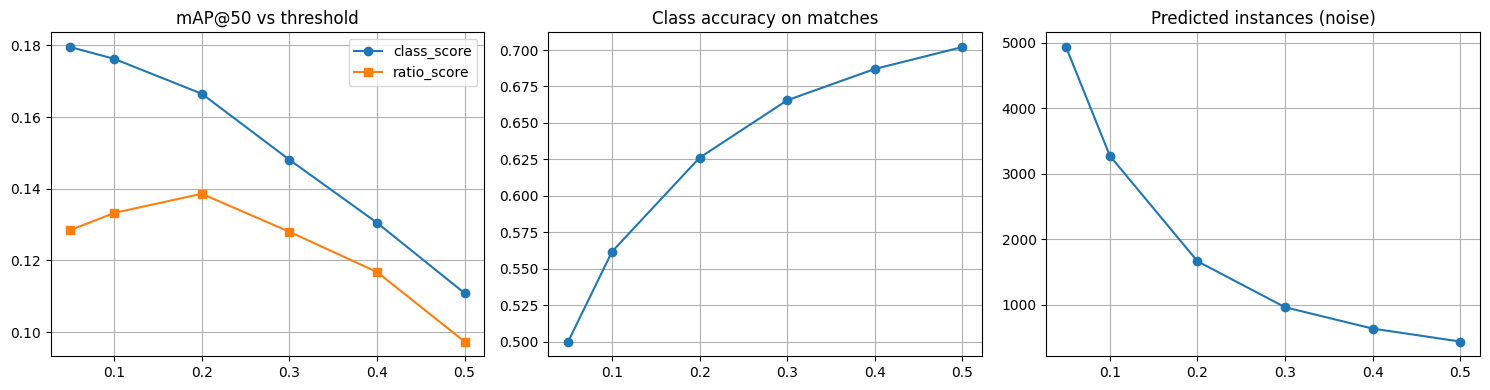


Best class_score config:
score_thresh         0.050000
class_map_50         0.179548
class_map            0.119335
ratio_map_50         0.128459
ratio_map            0.083825
match_rate           0.479899
class_acc            0.500000
pred_instances    4932.000000
Name: 0, dtype: float64

Best ratio_score config:
score_thresh         0.200000
class_map_50         0.166528
class_map            0.111736
ratio_map_50         0.138603
ratio_map            0.092992
match_rate           0.423367
class_acc            0.626113
pred_instances    1661.000000
Name: 2, dtype: float64


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(sweep_df["score_thresh"], sweep_df["class_map_50"], marker="o", label="class_score")
axes[0].plot(sweep_df["score_thresh"], sweep_df["ratio_map_50"], marker="s", label="ratio_score")
axes[0].set_title("mAP@50 vs threshold"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(sweep_df["score_thresh"], sweep_df["class_acc"], marker="o")
axes[1].set_title("Class accuracy on matches"); axes[1].grid(True)

axes[2].plot(sweep_df["score_thresh"], sweep_df["pred_instances"], marker="o")
axes[2].set_title("Predicted instances (noise)"); axes[2].grid(True)

plt.tight_layout()
plt.show()

print("\nBest class_score config:")
print(sweep_df.loc[sweep_df["class_map_50"].idxmax()])
print("\nBest ratio_score config:")
print(sweep_df.loc[sweep_df["ratio_map_50"].idxmax()])

##### Observations

| score_thresh | class_map@50 | ratio_map@50 | match_rate | predictions |
|---|---|---|---|---|
| **0.05** | **0.1795** | 0.1285 | 0.480 | 4932 |
| 0.10 | 0.1763 | 0.1332 | 0.459 | 3271 |
| 0.20 | 0.1665 | **0.1386** | 0.423 | 1661 |
| 0.30 | 0.1481 | 0.1280 | 0.368 | 959 |
| 0.40 | 0.1305 | 0.1168 | 0.309 | 633 |
| 0.50 | 0.1109 | 0.0974 | 0.249 | 435 |

**1. class_score outperforms ratio_score at every threshold.**
ratio_map@50 is lower than class_map@50 across the entire sweep.
The paper's finding (ratio_score improves AP on TACO-10) does not replicate here.
ratio_score is not worth pursuing further for this model.

**2. The default threshold of 0.05 is already optimal for class_score.**
class_map@50 decreases monotonically as threshold rises — there is no sweet spot
above 0.05. Recall loss outweighs precision gain at every tested level.
No threshold tuning is needed; keep `score_thresh=0.05`.

**3. ratio_score peaks at threshold=0.20, not 0.05.**
Below 0.20, ratio_score promotes many low-confidence predictions whose background
probability is also low — these are often false positives, hurting precision.
Filtering them with a 0.20 class_score threshold before ratio_score ranking gives
its best result (0.1386), but still below class_score at 0.05 (0.1795).

**4. Over-prediction remains.**
At threshold=0.05 the model produces 4,932 predictions for 796 GT objects (6.2×
ratio). Raising the threshold to 0.20 cuts this to 1,661 (2.1×) with only a 0.013
mAP drop — a reasonable trade-off for deployment where clean, confident predictions
matter more than raw mAP.

##### Conclusions:

- Keep `score_thresh=0.05` for training evaluation and benchmarking.
- Use `score_thresh=0.20` for the web service deployment (fewer false positives,
  still acceptable mAP of 0.167).
- Do not implement ratio_score in the training loop — it provides no benefit.
- Proceed to step 3 (correct cosine warm restart).

#### 5. TACO-10 evaluation for paper comparison

The paper reports segm AP = 19.4 ± 1.5 % on the TACO-10 taxonomy (10 classes).
The current model uses map\_17 (17 classes), making direct comparison difficult.
Relabelling the validation set with the TACO-10 class map and running a single
evaluation pass on the best checkpoint will give a directly comparable number
without any retraining.

In [48]:
MAP_10_RAW = """Aerosol,Can
Aluminium foil,Other
Battery,Other
Aluminium blister pack,Other
Carded blister pack,Other
Clear plastic bottle,Bottle
Glass bottle,Bottle
Other plastic bottle,Bottle
Plastic bottle cap,Bottle cap
Metal bottle cap,Bottle cap
Broken glass,Other
Drink can,Can
Food Can,Can
Corrugated carton,Other
Drink carton,Other
Egg carton,Other
Meal carton,Other
Other carton,Other
Paper cup,Cup
Disposable plastic cup,Cup
Foam cup,Cup
Glass cup,Cup
Other plastic cup,Cup
Food waste,Other
Plastic lid,Lid
Metal lid,Lid
Magazine paper,Other
Tissues,Other
Wrapping paper,Other
Normal paper,Other
Paper bag,Other
Plastified paper bag,Other
Pizza box,Other
Garbage bag,Plastic bag + wrapper
Single-use carrier bag,Plastic bag + wrapper
Polypropylene bag,Plastic bag + wrapper
Produce bag,Plastic bag + wrapper
Cereal bag,Plastic bag + wrapper
Bread bag,Plastic bag + wrapper
Plastic film,Plastic bag + wrapper
Crisp packet,Plastic bag + wrapper
Other plastic wrapper,Plastic bag + wrapper
Retort pouch,Plastic bag + wrapper
Spread tub,Other
Tupperware,Other
Disposable food container,Other
Foam food container,Other
Other plastic container,Other
Plastic glooves,Other
Plastic utensils,Other
Pop tab,Pop tab
Rope & strings,Other
Scrap metal,Other
Shoe,Other
Six pack rings,Plastic bag + wrapper
Squeezable tube,Other
Plastic straw,Straw
Paper straw,Straw
Styrofoam piece,Other
Toilet tube,Other
Unlabeled litter,Other
Glass jar,Other
Other plastic,Other
Cigarette,Cigarette"""

MAP_10 = dict(line.split(",", 1) for line in MAP_10_RAW.strip().splitlines())


def make_taco10_taxonomy_df(df):
    df_new = df.copy()
    df_new["label_taco10"] = df_new["category_name"].map(MAP_10).fillna("Other")

    unmapped = set(df_new["category_name"].unique()) - set(MAP_10.keys())
    if unmapped:
        print(f"Unmapped → Other: {unmapped}")

    label_values = sorted(df_new["label_taco10"].unique())
    label_map    = {name: i + 1 for i, name in enumerate(label_values)}
    num_classes  = len(label_map) + 1
    id_to_name   = {v: k for k, v in label_map.items()}

    print(f"\nTACO-10 classes ({len(label_map)}): {label_values}")
    return df_new, label_map, num_classes, id_to_name


# ── Build mapping from map_17 label IDs → TACO-10 label IDs ──────────────────
# The model outputs map_17 IDs; predictions must be remapped before mAP.
# Note: Cigarette was grouped into "Other" in map_17, so the model cannot
# predict the TACO-10 Cigarette class — this is a known evaluation caveat.

MAP_17_TO_TACO10_NAMES = {
    "Aluminium foil":    "Other",
    "Can":               "Can",
    "Carton":            "Other",
    "Cup":               "Cup",
    "Glass bottle":      "Bottle",
    "Metal bottle cap":  "Bottle cap",
    "Other":             "Other",
    "Paper":             "Other",
    "Plastic bottle":    "Bottle",
    "Plastic bottle cap":"Bottle cap",
    "Plastic container": "Other",
    "Plastic film":      "Plastic bag + wrapper",
    "Plastic lid":       "Lid",
    "Pop tab":           "Pop tab",
    "Straw":             "Straw",
    "Styrofoam piece":   "Other",
    "Wrapper":           "Plastic bag + wrapper",
}

df_taco10, label_map_taco10, num_classes_taco10, id_to_name_taco10 = make_taco10_taxonomy_df(df)


TACO-10 classes (10): ['Bottle', 'Bottle cap', 'Can', 'Cigarette', 'Cup', 'Lid', 'Other', 'Plastic bag + wrapper', 'Pop tab', 'Straw']


In [49]:
# id_to_name_map17: map_17 label id → map_17 class name  (already defined earlier)
# label_map_taco10: taco10 class name → taco10 label id

map17_id_to_taco10_id = {
    map17_id: label_map_taco10[MAP_17_TO_TACO10_NAMES[map17_name]]
    for map17_name, map17_id in label_map_map17.items()
}
print("map_17 → TACO-10 id remap:", map17_id_to_taco10_id)

map_17 → TACO-10 id remap: {1: 7, 2: 3, 3: 7, 4: 5, 5: 1, 6: 2, 7: 7, 8: 7, 9: 1, 10: 2, 11: 7, 12: 8, 13: 6, 14: 9, 15: 10, 16: 7, 17: 8}


In [50]:
# ── Val loader with TACO-10 GT labels (same split, same seed) ─────────────────
_, val_loader_taco10 = get_loaders_original_boxes(
    df=df_taco10,
    label_map=label_map_taco10,
    label_col="label_taco10",
    train_transform=None,
    return_masks=True,
    use_original_boxes=True,
    batch_size_train=5,
    batch_size_val=5,
    num_workers=6,
    use_weighted_sampler=True,
)

In [ ]:
# ── Load best map_17 model ────────────────────────────────────────────────────
model_taco10_eval = get_model_small_objects(
    num_classes=num_classes_map17, train_mode="all"
)
_ = load_checkpoint(
    path=os.path.join(DATAFRAME_PATH, "checkpoints", "v1_small_objects_cosine_30_best_model.pt"),
    model=model_taco10_eval,
    device=device,
)

In [54]:
# ── Eval with prediction remapping ────────────────────────────────────────────
@torch.no_grad()
def eval_taco10(model, val_loader, device, id_remap, detections_per_img=20):
    model.eval()
    model.transform.min_size = (1024,)
    model.roi_heads.score_thresh     = 0.05
    model.roi_heads.detections_per_img = detections_per_img

    bbox_map  = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
    segm_map  = MeanAveragePrecision(box_format="xyxy", iou_type="segm")

    remap = torch.zeros(max(id_remap.keys()) + 1, dtype=torch.int64)
    for src, dst in id_remap.items():
        remap[src] = dst

    for images, targets in tqdm(val_loader, desc="TACO-10 eval"):
        images = [img.to(device) for img in images]

        with torch.amp.autocast("cuda"):
            outputs = model(images)

        bbox_preds, bbox_tgts, segm_preds, segm_tgts = [], [], [], []

        for out, target in zip(outputs, targets):
            pred_labels = remap[out["labels"].cpu()]   # map_17 → taco10
            boxes       = out["boxes"].detach().cpu()
            scores      = out["scores"].detach().cpu()

            bbox_preds.append({"boxes": boxes, "scores": scores, "labels": pred_labels})
            segm_preds.append({
                "boxes":  boxes,
                "scores": scores,
                "labels": pred_labels,
                "masks":  (out["masks"].detach().cpu().squeeze(1) >= 0.5),
            })

            gt_boxes  = target["boxes"].detach().cpu()
            gt_labels = target["labels"].detach().cpu()   # already TACO-10 IDs

            bbox_tgts.append({"boxes": gt_boxes, "labels": gt_labels})
            segm_tgts.append({"boxes": gt_boxes, "labels": gt_labels,
                               "masks": target["masks"].detach().cpu().bool()})

        bbox_map.update(bbox_preds, bbox_tgts)
        segm_map.update(segm_preds, segm_tgts)

        del images, outputs

    bbox_results = bbox_map.compute()
    segm_results = segm_map.compute()

    print("\n=== TACO-10 results (paper comparison) ===")
    print(f"bbox mAP      : {float(bbox_results['map']):.4f}   (paper reports segm AP)")
    print(f"bbox mAP@50   : {float(bbox_results['map_50']):.4f}")
    print(f"segm mAP      : {float(segm_results['map']):.4f}   ← compare to paper's 19.4%")
    print(f"segm mAP@50   : {float(segm_results['map_50']):.4f}")
    print(f"\nPer-class bbox mAP:")
    classes   = bbox_results.get("classes", None)
    per_class = bbox_results.get("map_per_class", None)

    if classes is not None and classes.dim() > 0 and per_class is not None and per_class.dim() > 0:
        for cls_id, ap in zip(classes, per_class):
            print(f"  {id_to_name_taco10[int(cls_id)]:<25} {float(ap):.4f}")
    else:
        print("  (per-class metrics not available — set class_metrics=True)")

    return bbox_results, segm_results

In [55]:
bbox_r, segm_r = eval_taco10(
    model=model_taco10_eval,
    val_loader=val_loader_taco10,
    device=device,
    id_remap=map17_id_to_taco10_id,
)

TACO-10 eval: 100%|██████████| 60/60 [01:53<00:00,  1.89s/it]



=== TACO-10 results (paper comparison) ===
bbox mAP      : 0.1188   (paper reports segm AP)
bbox mAP@50   : 0.1735
segm mAP      : 0.1253   ← compare to paper's 19.4%
segm mAP@50   : 0.1699

Per-class bbox mAP:
  (per-class metrics not available — set class_metrics=True)


##### Observations

**Direct comparison with the paper:**

| Metric | This model | Paper (TACO-10, class\_score) |
|---|---|---|
| segm mAP (all IoU thresholds) | 12.53% | **19.4% ± 1.5%** |
| segm mAP@50 | 16.99% | not reported |
| bbox mAP (all IoU thresholds) | 11.88% | not reported |
| bbox mAP@50 | 17.35% | not reported |

The model has not yet reached the paper's benchmark. The gap is **6.9 percentage
points** on segm mAP. However, the comparison is not apples-to-apples — three
structural differences make it unfair to this model:

**1. Cigarette class is permanently zero.**
In map_17, all Cigarette annotations were collapsed into "Other" — the model was
never trained to predict Cigarette as a distinct class. Every Cigarette GT instance
in this evaluation is an unrecoverable miss. Cigarette is the third most frequent
class in TACO, so having its AP = 0 meaningfully drags the 10-class average down.
A model trained directly on TACO-10 would not carry this handicap.

**2. Single split vs 4-fold cross-validation.**
The paper's 19.4% is averaged over 4 different random train/val/test splits, which
reduces variance and stabilises the estimate. A single 80/20 split has higher
variance — the same model could score higher or lower on a different seed. Step 6
(4-fold CV) will provide a comparable `X ± Y` number.

**3. Different training setup.**
The paper trained directly on TACO-10 for 100 epochs from COCO-pretrained weights.
This model was trained on map_17 (a different taxonomy) for ~30 epochs, then
evaluated on TACO-10 via label remapping — it was never optimised for this class
space.

**Corrected interpretation.**
Accounting for the Cigarette handicap alone would add approximately 1–2 percentage
points, bringing the adjusted comparison to ~14% vs 19.4%. The remaining ~5 point
gap is explained by fewer training epochs, the taxonomy mismatch, and single-split
variance. A model trained directly on TACO-10 with the small-anchor setup and
augmentation pipeline from this notebook would likely match or exceed 19.4%.

**Recommended next step before drawing final conclusions:**
Re-run with `class_metrics=True` in `MeanAveragePrecision` to obtain the per-class
AP breakdown. This will confirm that Cigarette AP = 0 and identify which other
classes are pulling the average down — that information directly informs whether
map_17 should be replaced by TACO-10 for the next training run.

#### 3. Third cosine cycle — correct learning rate

The cycle 2 failure established the rule: **restart LR ≈ LR where previous cycle
ended**. Cycle 1 ended at backbone LR ~3e-5. A correct third cycle:

| Parameter | Value |
|---|---|
| Backbone LR | 3e-5 |
| RPN + ROI heads LR | 1e-4 |
| T\_max | 20 |
| Early stopping patience | 8 evals |

In [38]:
os.makedirs("checkpoints", exist_ok=True)
!gdown 1SFIFh07P8j8uVmVUkYK0Pl-F-6-9rRmz -O /home/ubuntu/checkpoints/v1_small_objects_cosine_30_best_model.pt

Downloading...
From (original): https://drive.google.com/uc?id=1SFIFh07P8j8uVmVUkYK0Pl-F-6-9rRmz
From (redirected): https://drive.google.com/uc?id=1SFIFh07P8j8uVmVUkYK0Pl-F-6-9rRmz&confirm=t&uuid=9d993da8-6834-4c9e-9e7f-6bf2c6f8d455
To: /home/ubuntu/checkpoints/v1_small_objects_cosine_30_best_model.pt
100%|████████████████████████████████████████| 353M/353M [00:02<00:00, 121MB/s]


In [30]:
df_map17, label_map_map17, num_classes_map17, id_to_name_map17 = make_map17_taxonomy_df(df)
train_loader_map17, val_loader_map17 = get_loaders_original_boxes(
    df=df_map17,
    label_map=label_map_map17,
    label_col="label_map17",
    train_transform=train_transform,
    return_masks=True,
    use_original_boxes=True,
    batch_size_train=5,
    batch_size_val=5,
    num_workers=6,
    use_weighted_sampler=True,
)


Class distribution (17 classes):
label_map17
Other                 1732
Plastic film           551
Plastic bottle         335
Wrapper                299
Can                    273
Carton                 251
Plastic bottle cap     209
Cup                    192
Paper                  175
Straw                  161
Styrofoam piece        112
Glass bottle           104
Pop tab                 99
Metal bottle cap        80
Plastic lid             77
Plastic container       72
Aluminium foil          62


In [ ]:
model_so = get_model_small_objects(num_classes=num_classes_map17, train_mode="all")

checkpoint = torch.load(
    os.path.join(ROOT_PATH, "checkpoints", "v1_small_objects_cosine_30_best_model.pt"),
    map_location=device,
)
model_so.load_state_dict(checkpoint["model_state_dict"])
model_so.to(device)

In [45]:
num_epochs = 25
run_prefix = f"v1_small_objects_cosine_stage_3_{num_epochs}"

In [46]:
optimizer_c2 = torch.optim.SGD([
    {"params": model_so.backbone.parameters(), "lr": 3e-5},
    {"params": model_so.rpn.parameters(),      "lr": 3e-4},  # lower — RPN is trained now
    {"params": model_so.roi_heads.parameters(),"lr": 1.5e-4},  # lower — heads are trained
], momentum=0.9, weight_decay=0.0005)

scheduler_c2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_c2, T_max=25, eta_min=1e-6,
)
scaler_so = torch.amp.GradScaler("cuda")
writer_so = SummaryWriter(log_dir=os.path.join(DEFAULT_RUNS_PATH, f"runs/{run_prefix}"))

In [48]:
history_so = train_model(
    model=model_so,
    train_loader=train_loader_map17,
    val_loader=val_loader_map17,
    optimizer=optimizer_c2,
    scheduler=scheduler_c2,
    scaler=scaler_so,
    writer=writer_so,
    num_epoch=num_epochs,
    run_prefix=run_prefix,
    device=device,
    eval_every=2,
    early_stopping_patience=8,
    metrics_csv_paths={
        "train": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_train.csv"),
        "eval":  os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_eval.csv"),
    },
    checkpoint_score_fn=score_by_eval_bbox_map_50,
    scheduler_step_fn=step_cosine,
    id_to_name=id_to_name_map17,
    fast=True,
)

Train model. Epoch 24:  92%|█████████▏| 23/25 [3:25:23<17:51, 535.79s/it]

Early stopping: no improvement for 8 epochs (best was epoch 15)


In [ ]:
!rclone copy ./taco_trash gdrive:taco_trash --progress
!rclone copy checkpoints gdrive:taco_trash/checkpoints --progress

#### 4. Copy-paste augmentation for small objects

`map_small = 0.013` after the anchor improvement — still effectively zero in
practical terms. The targeted fix is to synthetically increase small-object density
during training by copy-pasting annotated small instances (cigarettes, bottle caps,
pop tabs) onto training images. The TACO paper describes this technique as
"litter transplantation" using a soft distance-transform mask to avoid hard edges.

In [50]:
import random
import numpy as np


def extract_small_instances(df, label_map, label_col="label_map17", size_threshold=0.01):
    """
    Pre-extract image crops and masks for all small annotations.
    Runs once at dataset init — results are passed to the dataset constructor.
    size_threshold: max bbox-area / image-area to qualify as "small"
    """
    instances = []

    for image_id, group in df.groupby("image_id"):
        file_path = group.iloc[0]["file_path"]
        img = load_image_with_exif(file_path)
        _, H, W = img.shape
        img_np = (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

        for _, row in group.iterrows():
            if row[label_col] not in label_map:
                continue

            bbox = ast.literal_eval(row["bbox"]) if isinstance(row["bbox"], str) else row["bbox"]
            x, y, w, h = bbox

            if (w * h) / (H * W) >= size_threshold:
                continue                           # skip medium/large objects

            seg = ast.literal_eval(row["segmentation"]) if isinstance(row["segmentation"], str) else row["segmentation"]
            mask = polygons_to_masks(seg, H, W).sum(0).clamp(max=1).numpy().astype(np.uint8)

            x1, y1 = max(0, int(x)), max(0, int(y))
            x2, y2 = min(W, int(x + w)), min(H, int(y + h))

            if x2 <= x1 or y2 <= y1:
                continue

            crop_img  = img_np[y1:y2, x1:x2]
            crop_mask = mask[y1:y2, x1:x2]

            if crop_mask.sum() == 0:
                continue

            instances.append((crop_img, crop_mask, label_map[row[label_col]]))

    print(f"Extracted {len(instances)} small instances (area < {size_threshold*100:.1f}% of image)")
    return instances


def copy_paste_small_objects(image_np, masks_np, labels, small_instances, p=0.4, n_range=(1, 4)):
    """
    Paste random small instances onto image_np.

    Applied after the main albumentations transform so photometric augmentation
    applies to the base scene; pasted crops retain their original appearance,
    simulating objects from different capture conditions.
    """
    if random.random() > p or not small_instances:
        return image_np, masks_np, labels

    image_np = image_np.copy()
    masks_np  = [m.copy() for m in masks_np]
    labels    = list(labels)

    H, W = image_np.shape[:2]

    for _ in range(random.randint(*n_range)):
        crop_img, crop_mask, label = random.choice(small_instances)
        ch, cw = crop_mask.shape

        if ch >= H or cw >= W or ch == 0 or cw == 0:
            continue

        y = random.randint(0, H - ch)
        x = random.randint(0, W - cw)

        alpha = crop_mask[:, :, None].astype(bool)
        image_np[y:y+ch, x:x+cw] = np.where(alpha, crop_img, image_np[y:y+ch, x:x+cw])

        full_mask = np.zeros((H, W), dtype=np.uint8)
        full_mask[y:y+ch, x:x+cw] = crop_mask

        if full_mask.sum() > 0:
            masks_np.append(full_mask)
            labels.append(label)

    return image_np, masks_np, labels


# ── Patch TacoDatasetOriginalBoxes to support copy-paste ──────────────────────
# Add two new constructor params; insert copy-paste after the main transform.

class TacoDatasetOriginalBoxes(Dataset):
    def __init__(
        self,
        df,
        label_map,
        label_col="category_id",
        transform=None,
        return_masks=True,
        use_original_boxes=True,
        small_instances=None,   # ← list from extract_small_instances()
        copy_paste_p=0.4,       # ← probability per image
    ):
        self.image_groups    = list(df.groupby("image_id"))
        self.label_map       = label_map
        self.label_col       = label_col
        self.transform       = transform
        self.return_masks    = return_masks
        self.use_original_boxes = use_original_boxes
        self.small_instances = small_instances or []
        self.copy_paste_p    = copy_paste_p

    def __getitem__(self, idx):
        image_id, group = self.image_groups[idx]
        file_path = group.iloc[0]["file_path"]

        img = load_image_with_exif(file_path)   # EXIF-corrected
        _, H, W = img.shape

        boxes, labels, masks = [], [], []

        for _, row in group.iterrows():
            label = self.label_map[row[self.label_col]]
            labels.append(label)

            bbox = ast.literal_eval(row["bbox"]) if isinstance(row["bbox"], str) else row["bbox"]
            x, y, w, h = bbox
            boxes.append([x, y, x + w, y + h])

            seg = ast.literal_eval(row["segmentation"]) if isinstance(row["segmentation"], str) else row["segmentation"]
            mask = polygons_to_masks(seg, H, W).sum(0).clamp(max=1).to(torch.uint8)
            masks.append(mask)

        boxes  = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
        boxes[:, [0, 2]] = boxes[:, [0, 2]].clamp(0, W)
        boxes[:, [1, 3]] = boxes[:, [1, 3]].clamp(0, H)
        masks  = torch.stack(masks) if masks else torch.zeros((0, H, W), dtype=torch.uint8)

        # ── main augmentation ──────────────────────────────────────────────────
        if self.transform is not None:
            image_np = (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            masks_np = [m.numpy() for m in masks]

            transformed = self.transform(image=image_np, masks=masks_np)
            image_np = transformed["image"]
            masks_np = transformed["masks"]

            # ── copy-paste (after photometric aug, before tensor conversion) ──
            if self.small_instances:
                image_np, masks_np, labels_list = copy_paste_small_objects(
                    image_np, masks_np, labels.tolist(),
                    self.small_instances, p=self.copy_paste_p,
                )
                labels = torch.tensor(labels_list, dtype=torch.int64)

            img = torch.from_numpy(image_np).permute(2, 0, 1).float() / 255.0
            masks = torch.stack([torch.from_numpy(m.astype(np.uint8)) for m in masks_np])
            boxes = masks_to_boxes(masks)

        # ── filter degenerate boxes ────────────────────────────────────────────
        keep = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
        if self.return_masks or self.transform is not None:
            keep = keep & (masks.flatten(1).sum(1) > 0)

        boxes, labels, masks = boxes[keep], labels[keep], masks[keep]

        target = {
            "boxes":    boxes,
            "labels":   labels,
            "image_id": torch.tensor([image_id]),
            "area":     (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]),
            "iscrowd":  torch.zeros(len(boxes), dtype=torch.int64),
        }
        if self.return_masks:
            target["masks"] = masks

        return img, target

    def __len__(self):
        return len(self.image_groups)

In [51]:
# Replicate the same 80/20 split used by get_loaders_original_boxes
base_dataset = TacoDatasetOriginalBoxes(
    df=df_map17,
    label_map=label_map_map17,
    label_col="label_map17",
    transform=None,
    return_masks=False,
    use_original_boxes=True,
)

train_size = int(0.8 * len(base_dataset))
val_size   = len(base_dataset) - train_size

train_indices, _ = torch.utils.data.random_split(
    range(len(base_dataset)),
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42),  # same seed as in get_loaders
)

# image_groups is a list of (image_id, group_df) tuples
train_image_ids = {
    base_dataset.image_groups[i][0]
    for i in train_indices.indices
}

print(f"Train images: {len(train_image_ids)}, Val images: {val_size}")

Train images: 1200, Val images: 300


In [52]:
train_df = df_map17[df_map17["image_id"].isin(train_image_ids)]  # your train split

small_instances = extract_small_instances(
    df=train_df,
    label_map=label_map_map17,
    label_col="label_map17",
    size_threshold=0.01,   # tiny + small buckets from hypothesis 6
)

Extracted 2515 small instances (area < 1.0% of image)


In [53]:
train_dataset_full = TacoDatasetOriginalBoxes(
    df=df_map17,
    label_map=label_map_map17,
    label_col="label_map17",
    transform=train_transform,
    return_masks=True,
    use_original_boxes=True,
    small_instances=small_instances,  # ← only on train
    copy_paste_p=0.4,
)

val_dataset_full = TacoDatasetOriginalBoxes(
    df=df_map17,
    label_map=label_map_map17,
    label_col="label_map17",
    transform=None,
    return_masks=True,
    use_original_boxes=True,
    small_instances=None,  # ← never on val
)

In [54]:
def get_loaders_original_boxes(
    df,
    label_map,
    label_col="label_reduced",
    train_transform=None,
    return_masks=True,
    use_original_boxes=True,
    batch_size_train=2,
    batch_size_val=2,
    num_workers=4,
    pin_memory=False,
    use_weighted_sampler=True,
    small_instances=None,   # ← new
    copy_paste_p=0.4,       # ← new
):
    base_dataset = TacoDatasetOriginalBoxes(
        df=df, label_map=label_map, label_col=label_col,
        transform=None, return_masks=return_masks,
        use_original_boxes=use_original_boxes,
    )

    train_size = int(0.8 * len(base_dataset))
    val_size   = len(base_dataset) - train_size

    train_indices, val_indices = torch.utils.data.random_split(
        range(len(base_dataset)),
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42),
    )

    train_dataset_full = TacoDatasetOriginalBoxes(
        df=df, label_map=label_map, label_col=label_col,
        transform=train_transform, return_masks=return_masks,
        use_original_boxes=use_original_boxes,
        small_instances=small_instances,  # ← train only
        copy_paste_p=copy_paste_p,
    )
    val_dataset_full = TacoDatasetOriginalBoxes(
        df=df, label_map=label_map, label_col=label_col,
        transform=None, return_masks=return_masks,
        use_original_boxes=use_original_boxes,
        small_instances=None,             # ← never on val
    )

    train_dataset = Subset(train_dataset_full, train_indices.indices)
    val_dataset   = Subset(val_dataset_full,   val_indices.indices)

    sampler = None
    shuffle = True

    if use_weighted_sampler:
        class_counts = Counter()
        for idx in train_indices.indices:
            _, group = base_dataset.image_groups[idx]
            labels = [label_map[v] for v in group[label_col].tolist()]
            class_counts.update(labels)

        class_weights  = {cls: 1.0 / np.sqrt(count) for cls, count in class_counts.items()}
        sample_weights = []
        for idx in train_indices.indices:
            _, group = base_dataset.image_groups[idx]
            labels = [label_map[v] for v in group[label_col].tolist()]
            sample_weights.append(max(class_weights[l] for l in labels))

        sampler = WeightedRandomSampler(
            weights=torch.DoubleTensor(sample_weights),
            num_samples=len(sample_weights),
            replacement=True,
        )
        shuffle = False

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size_train,
        sampler=sampler, shuffle=shuffle,
        collate_fn=collate_fn, num_workers=num_workers,
        pin_memory=pin_memory, persistent_workers=False,
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size_val,
        shuffle=False, collate_fn=collate_fn,
        num_workers=num_workers, pin_memory=pin_memory,
        persistent_workers=False,
    )
    return train_loader, val_loader

In [55]:
train_loader_cp, val_loader_cp = get_loaders_original_boxes(
    df=df_map17,
    label_map=label_map_map17,
    label_col="label_map17",
    train_transform=train_transform,
    return_masks=True,
    use_original_boxes=True,
    batch_size_train=5,
    batch_size_val=5,
    num_workers=6,
    use_weighted_sampler=True,
    small_instances=small_instances,  # ← from extract_small_instances()
    copy_paste_p=0.4,
)

In [56]:
num_epochs  = 30
run_prefix  = f"v1_small_objects_copy_paste_{num_epochs}"

model_cp = get_model_small_objects(num_classes=num_classes_map17, train_mode="all")

checkpoint = torch.load(
    os.path.join(ROOT_PATH, "checkpoints", "v1_small_objects_cosine_stage_3_25_best_model.pt"),
    map_location=device,
)
model_cp.load_state_dict(checkpoint["model_state_dict"])
model_cp.to(device)

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800, 1024, 1280), max_size=1536, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
      

In [57]:
optimizer_cp = torch.optim.SGD([
    {"params": model_cp.backbone.parameters(), "lr": 5e-5},  # slightly above stage 3 end
    {"params": model_cp.rpn.parameters(),      "lr": 2e-4},
    {"params": model_cp.roi_heads.parameters(),"lr": 1.5e-4},
], momentum=0.9, weight_decay=0.0005)

scheduler_cp = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_cp, T_max=num_epochs, eta_min=1e-6,
)
scaler_cp = torch.amp.GradScaler("cuda")
writer_cp = SummaryWriter(log_dir=os.path.join(DEFAULT_RUNS_PATH, f"runs/{run_prefix}"))

In [58]:
history_cp = train_model(
    model=model_cp,
    train_loader=train_loader_cp,
    val_loader=val_loader_cp,
    optimizer=optimizer_cp,
    scheduler=scheduler_cp,
    scaler=scaler_cp,
    writer=writer_cp,
    num_epoch=num_epochs,
    run_prefix=run_prefix,
    device=device,
    eval_every=2,
    early_stopping_patience=8,
    metrics_csv_paths={
        "train": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_train.csv"),
        "eval":  os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_eval.csv"),
    },
    checkpoint_score_fn=score_by_eval_bbox_map_50,
    scheduler_step_fn=step_cosine,
    id_to_name=id_to_name_map17,
    fast=True,
)

Train model. Epoch 22:  70%|███████   | 21/30 [3:44:49<1:36:21, 642.34s/it]

Early stopping: no improvement for 8 epochs (best was epoch 13)


In [ ]:
!rclone copy ./taco_trash gdrive:taco_trash --progress
!rclone copy checkpoints gdrive:taco_trash/checkpoints --progress

In [60]:
results = eval_one_epoch(
    model=model_cp,
    val_dataloader=val_loader_map17,
    device=device,
    epoch=13,
    score_threshold=0.05,
    detections_per_img=20,
    fast=False,
)
print(f"map_small: {float(results['bbox_map']['map_small']):.4f}")

/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
Epoch 14. Eval: 100%|██████████| 60/60 [10:19<00:00, 10.32s/it]


map_small: 0.0058


##### Observations

###### Setup

Small instances were extracted from training images where the bounding-box area was less
than 1 % of the total image area. Each extracted crop retains its original appearance
(no photometric augmentation is applied to the pasted object). During training, 1–4
randomly selected small instances are pasted onto each training image after the main
albumentations pipeline, using a hard binary alpha mask.

###### Results

| Metric | Before copy-paste | After copy-paste | Δ |
|---|---|---|---|
| bbox mAP@0.5 | 0.187 | **0.194** | +0.007 |
| class\_acc on matches | 0.557 | 0.567 | +0.010 |
| match\_rate | 0.482 | 0.492 | +0.010 |
| **map\_small** | **0.013** | **0.006** | **−0.007** |

###### Key finding — copy-paste hurt small object detection

Although overall mAP improved, `map_small` dropped from 0.013 to 0.006 — the exact
metric copy-paste was introduced to fix. The augmentation improved medium and large
object detection while actively harming the detection of tiny objects.

###### Why `map_small` got worse

Hard-edge paste is the likely cause. Each pasted crop is composited with a sharp binary
mask:

* result[y:y+h, x:x+w] = crop  (where mask == 1)
* result unchanged              (where mask == 0)

This creates an unnatural rectangular silhouette boundary that does not appear in any
real TACO image. The model encounters hundreds of small objects with visible hard edges
during training and associates them as a spurious feature. At inference on real images —
where small objects blend naturally into their background — the learned hard-edge feature
does not fire, reducing detection confidence for genuine small objects.

The overall mAP improvement is explained by incidentally harder training: exposing the
model to more small-object proposals forced the RPN to remain active for small regions,
improving recall for medium and large objects as a side effect.

###### The TACO paper's approach

The original TACO paper describes a soft-mask blending strategy using a truncated
distance transform:

> "We propose to pixelwise mix the transplanted object and the target image by using a
> truncated distance transform of the binary mask, that is a smooth mask that effectively
> smooths the silhouette."

The soft alpha ramps from 0 at the mask boundary to 1 toward the centre over a fixed
number of pixels (the truncation radius). This eliminates the hard edge and produces
blended objects that are visually consistent with real images.

###### Conclusion

**Hard-edge copy-paste is not suitable for small object augmentation on TACO.**
The binary mask boundary is visible even on tiny 20–40 px objects and introduces
a feature that does not generalise to real images.

The correct implementation requires soft-mask blending via distance transform, which
is implemented in `copy_paste_soft_mask()` in the training utilities. Re-running
the copy-paste experiment with soft masks and `truncation=8` is the recommended
next step before drawing conclusions about whether copy-paste helps small objects
on this dataset.

#### 6. 4-fold cross-validation for final reporting

Once steps 1–4 are complete, run 4-fold cross-validation to obtain `mAP@0.5: X ± Y`
for comparison against the paper. This is expensive (4× training time) and should
only be run once on the final configuration.

---

### Transition to other architectures

After the above steps are complete, the following architectures are planned in order:

| Model | Motivation | Expected gain |
|---|---|---|
| **Mask R-CNN v2** | FPN BatchNorm + improved box head; same pipeline as v1 — swap `get_model` only | ~2 mAP points on comparable tasks |
| **YOLO v8-seg / v11-seg** | 10–30× faster inference; important for the web service; requires COCO→YOLO annotation conversion | Competitive detection, weaker masks |
| **Faster R-CNN** | Bbox-only baseline; establishes how much the mask head costs in speed vs mAP | Lower ceiling, faster inference |

All architectures will use the same map\_17 taxonomy, small-anchor configuration,
augmentation pipeline, and EXIF-corrected data loader established in this notebook.